In [213]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (r2_score, mean_squared_error,
                             classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [185]:
df = pd.read_excel("Games_final.xlsx")
print(df.head())

                       Name Platform  Year         Genre Publisher  NA_Sales  \
0                Wii Sports      Wii  2006        Sports  Nintendo     41.49   
1         Super Mario Bros.      NES  1985      Platform  Nintendo     29.08   
2            Mario Kart Wii      Wii  2008        Racing  Nintendo     15.85   
3         Wii Sports Resort      Wii  2009        Sports  Nintendo     15.75   
4  Pokemon Red/Pokemon Blue       GB  1996  Role-Playing  Nintendo     11.27   

   EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     29.02      3.77         8.46         82.74  
1      3.58      6.81         0.77         40.24  
2     12.88      3.79         3.31         35.82  
3     11.01      3.28         2.96         33.00  
4      8.89     10.22         1.00         31.37  


#### defining colour palette 

In [186]:
PALETTE = ['#2C3E50','#E74C3C','#3498DB','#2ECC71','#F39C12',
           '#9B59B6','#1ABC9C','#E67E22',"#E1FF02",'#E91E63',
           '#00BCD4','#8BC34A']
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

##### making Cluster of game series 

In [187]:
# ── 2d. Create Platform Family column ───────────────────────
platform_families = {
    'Nintendo Home'      : ['NES','SNES','N64','GC','Wii','WiiU'],
    'Nintendo Handheld'  : ['GB','GBA','DS','3DS'],
    'PlayStation Home'   : ['PS','PS2','PS3','PS4'],
    'PlayStation Handheld': ['PSP','PSV'],
    'Xbox'               : ['XB','X360','XOne'],
    'Atari'              : ['2600'],
    'Sega'               : ['GEN','DC','SAT','SCD','GG'],
    'PC'                 : ['PC'],
    'Other'              : ['3DO','NG','PCFX','TG16','WS'],
}
df['Platform_Family'] = 'Other'
for family, platforms in platform_families.items():
    df.loc[df['Platform'].isin(platforms), 'Platform_Family'] = family

# ── 2e. Create Game Series (Game Family) column ──────────────
series_map = {
    'Mario'            : ['Mario'],
    'Pokemon'          : ['Pokemon', 'Pokémon'],
    'Call of Duty'     : ['Call of Duty'],
    'Grand Theft Auto' : ['Grand Theft Auto', 'GTA'],
    'FIFA'             : ['FIFA'],
    'Final Fantasy'    : ['Final Fantasy'],
    'Zelda'            : ['Zelda'],
    'Sonic'            : ['Sonic'],
    'Halo'             : ['Halo'],
    "Assassin's Creed" : ["Assassin's Creed"],
    'Madden NFL'       : ['Madden'],
    'Gran Turismo'     : ['Gran Turismo'],
    'Need for Speed'   : ['Need for Speed'],
    'Dragon Quest'     : ['Dragon Quest'],
    'Resident Evil'    : ['Resident Evil'],
    'Donkey Kong'      : ['Donkey Kong'],
    'Battlefield'      : ['Battlefield'],
    'Kirby'            : ['Kirby'],
    'NBA 2K'           : ['NBA 2K'],
    'WWE'              : ['WWE'],
    'Wii Sports'        : ['Wii Sports'],
    'Just Dance'        : ['Just Dance'],
    'Sonic'           : ['Sonic'],
    'star Wars'         : ['Star Wars', 'StarWars', 'Star War'],
    'Tony Hawk'         : ['Tony Hawk', 'THPS', 'THUG'],
}
df['Game_Series'] = 'Standalone'
for series, keywords in series_map.items():
    mask = df['Name'].str.contains('|'.join(keywords), case=False, na=False)
    df.loc[mask, 'Game_Series'] = series
    
series_games = (df['Game_Series'] != 'Standalone').sum()


# ── 2f. Decade column ────────────────────────────────────────
df['5_Year_period'] = (df['Year'] // 5) * 5

# RQ1 Which genres and platforms dominates global sales.

In [188]:
print("\n=== GENRE SUMMARY ===")
genre_summary = df.groupby('Genre').agg(
    Total_Sales   = ('Global_Sales', 'sum'),
).sort_values('Total_Sales', ascending=False)
genre_summary['Share_%'] = (genre_summary['Total_Sales'] /
                             genre_summary['Total_Sales'].sum() * 100).round(1)
print(genre_summary.round(2))


=== GENRE SUMMARY ===
              Total_Sales  Share_%
Genre                             
Action            1734.56     19.6
Sports            1319.42     14.9
Shooter           1032.62     11.7
Role-Playing       923.83     10.4
Platform           830.16      9.4
Misc               798.40      9.0
Racing             727.98      8.2
Fighting           447.05      5.0
Simulation         389.98      4.4
Puzzle             242.21      2.7
Adventure          238.28      2.7
Strategy           173.27      2.0


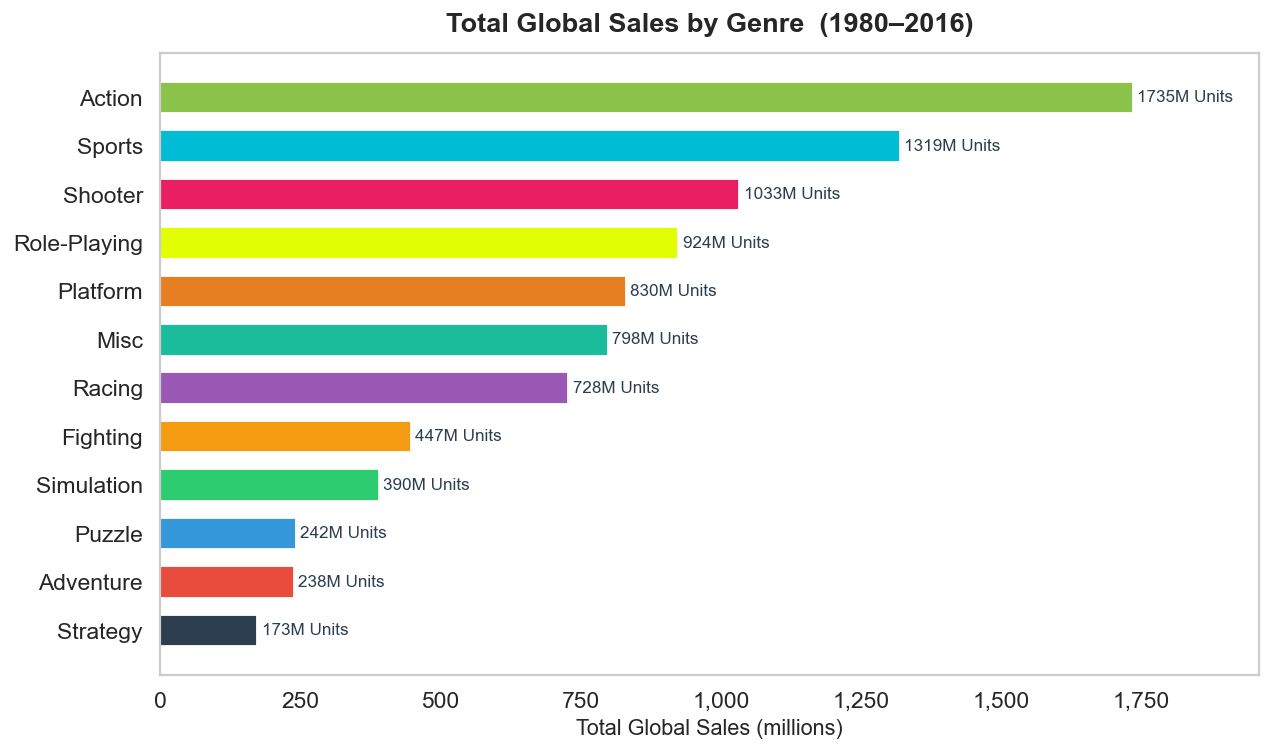

In [189]:
genre_sales = genre_summary['Total_Sales'].sort_values()   # ascending for barh

fig, ax = plt.subplots(figsize=(10, 6))
colors_g = PALETTE[:len(genre_sales)]
bars = ax.barh(genre_sales.index, genre_sales.values,
               color=colors_g, edgecolor='white', height=0.65)

# value labels
for bar, val in zip(bars, genre_sales.values):
    ax.text(val + 8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}M Units', va='center', fontsize=9.5, color='#2C3E50')

ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Total Global Sales by Genre  (1980–2016)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlim(0, genre_sales.max() * 1.13)
ax.grid(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

##### Figure 1: Total global sales (millions) by genre.
Figure 1 shows total global sales by genre. Action games lead with over 1,735 million units sold, followed by Sports (1,319 M) and Shooter (1,033 M). Strategy games sit at the lower end, reflecting niche audiences.

In [190]:
print("\n=== TOP 10 PLATFORMS BY TOTAL SALES ===")
platform_summary = df.groupby('Platform').agg(
    Total_Sales = ('Global_Sales', 'sum'),
    Num_Games   = ('Name', 'count'),
 
).sort_values('Total_Sales', ascending=False)

print(platform_summary.head(10).round(2))


=== TOP 10 PLATFORMS BY TOTAL SALES ===
          Total_Sales  Num_Games
Platform                        
PS2           1247.51       2132
X360           972.08       1235
PS3            950.97       1304
Wii            921.10       1295
DS             818.91       2131
PS             729.89       1191
GBA            309.22        788
PSP            293.03       1198
PS4            278.10        336
PC             256.33        939


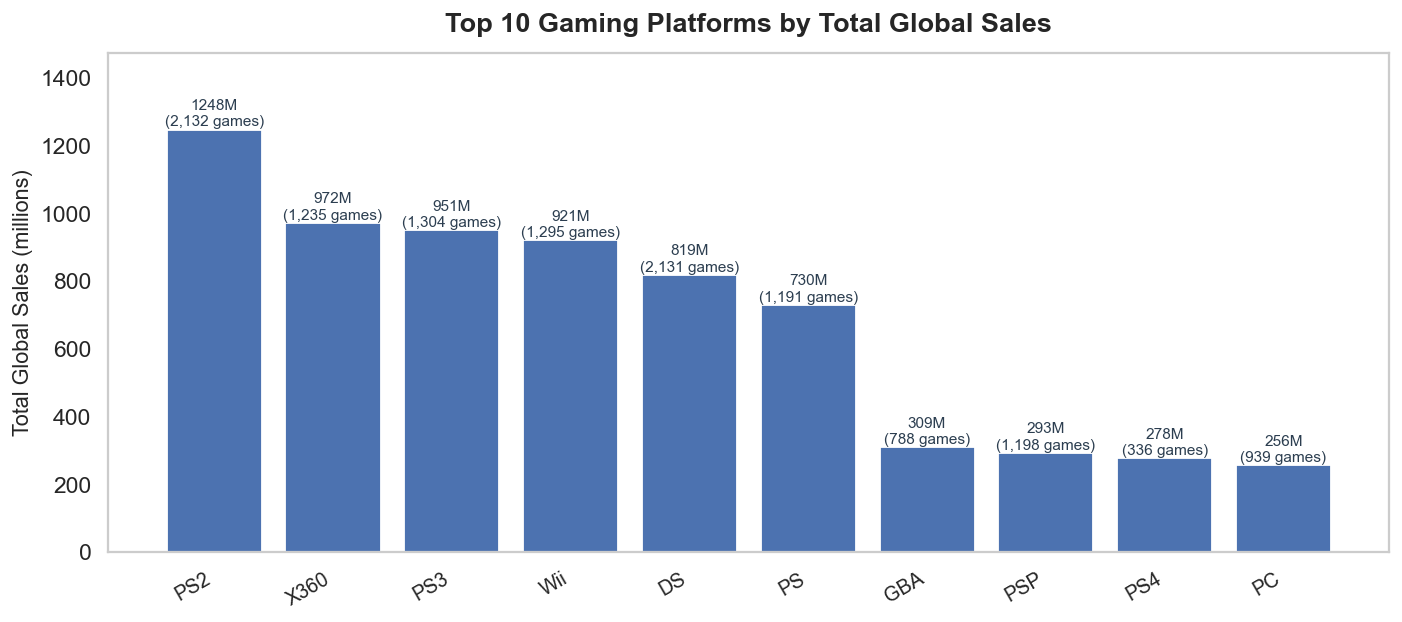

In [191]:
top10_plat = platform_summary.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(top10_plat)), top10_plat['Total_Sales'].values)
           
ax.set_xticks(range(len(top10_plat)))
ax.set_xticklabels(top10_plat.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 10 Gaming Platforms by Total Global Sales',
             fontsize=15, fontweight='bold', pad=12)
for i, (val, games) in enumerate(zip(top10_plat['Total_Sales'], top10_plat['Num_Games'])):
    ax.text(i, val + 10, f'{val:.0f}M\n({games:,} games)',
            ha='center', fontsize=8.5, color='#2C3E50')
ax.set_ylim(0, top10_plat['Total_Sales'].max() * 1.18)
ax.grid(False)
plt.tight_layout()
plt.show()

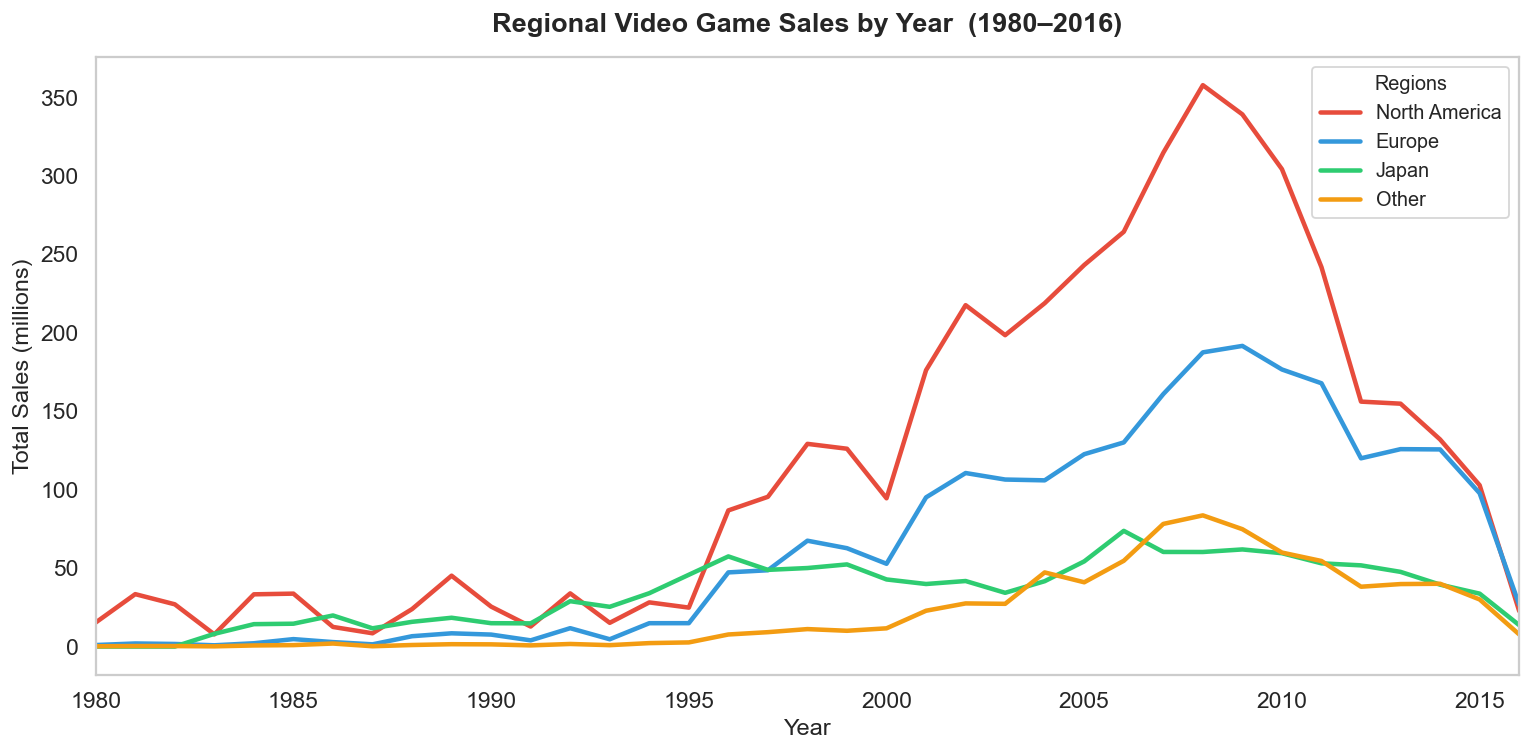

In [192]:
time_region = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()

# PLOT 
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
labels = ['North America', 'Europe', 'Japan', 'Other']

for col, color, label in zip(time_region.columns, colors, labels):
    ax.plot(time_region.index, time_region[col],
            color=color, linewidth=2.5, label=label, markersize=3)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Total Sales (millions)', fontsize=13)
ax.set_title('Regional Video Game Sales by Year  (1980–2016)',
             fontsize=15, fontweight='bold', pad=14)
ax.legend(title='Regions', fontsize=11, title_fontsize=11)
ax.set_xlim(1980, 2016)
ax.grid(False)
plt.tight_layout()
plt.show()

##### Figure 2: Annual regional sales trends (1980–2016). 
Tracks regional sales by year. The industry experienced a dramatic expansion between 2000 and 2008, peaking around 2008–2009  coinciding with the Nintendo Wii and DS boom. North America consistently leads all regions. Japan's trajectory is notably flatter, reflecting its mature and distinct domestic market. All regions decline post-2010 in the dataset, though this partly reflects data sparsity for recent years rather than an actual industry contraction.

# RQ2  Regional Market Differences

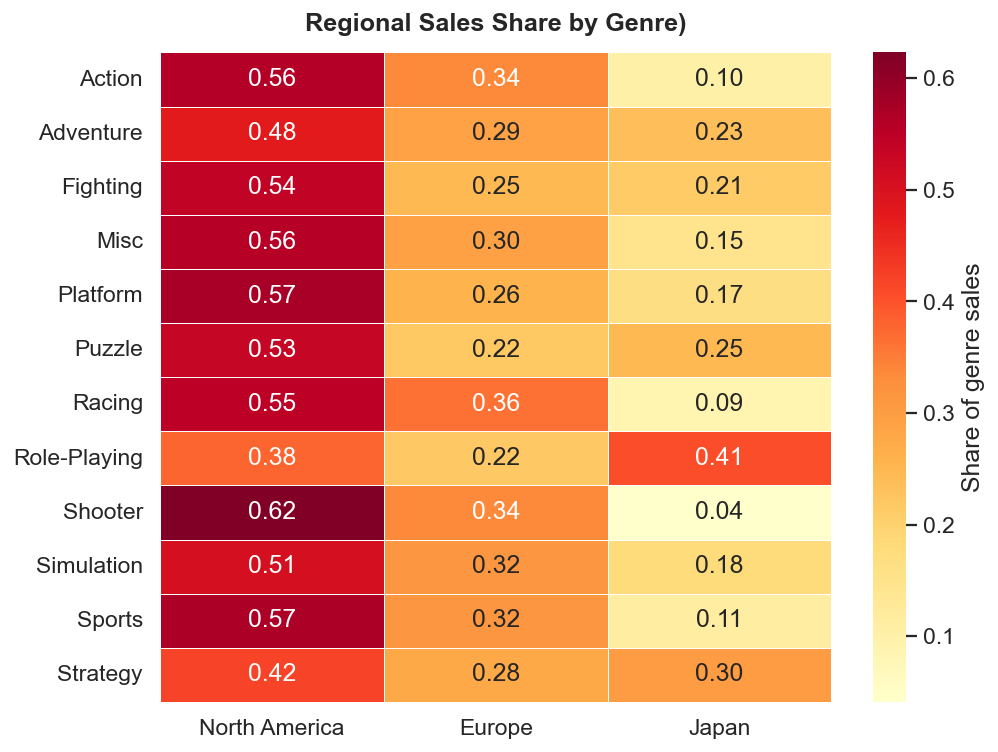

In [193]:
reg_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
reg_genre_norm = reg_genre.div(reg_genre.sum(axis=1), axis=0)   # row-wise share
reg_genre_norm.columns = ['North America', 'Europe', 'Japan']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    reg_genre_norm,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Share of genre sales'}
)
ax.set_title('Regional Sales Share by Genre)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

##### To test whether regional tastes differ, we computed each region's share of sales within each genre. Figure 3 visualises these shares as a heatmap.
Several patterns stand out. Japan commands a much higher share of Role-Playing genre
sales (typically >40%) compared to its modest share in Shooter or Sports genres. This is
consistent with Japan's historical strength in JRPG franchises (Final Fantasy, Dragon Quest,
Pokemon). North America dominates Shooter and Sports genres, both reflecting culturally
embedded preferences (American football simulations, first-person shooters). Europe's share is
broadly proportional across genres, with a slight over-index in Racing and Fighting.
To quantify regional similarity, we computed Pearson correlations between regional sales
vectors at the game level. NA and EU sales are strongly correlated (r = 0.77), indicating broadly
shared Western preferences. JP sales are much less correlated with NA (r = 0.33) and EU (r =
0.29), confirming that Japan constitutes a distinctly different market.

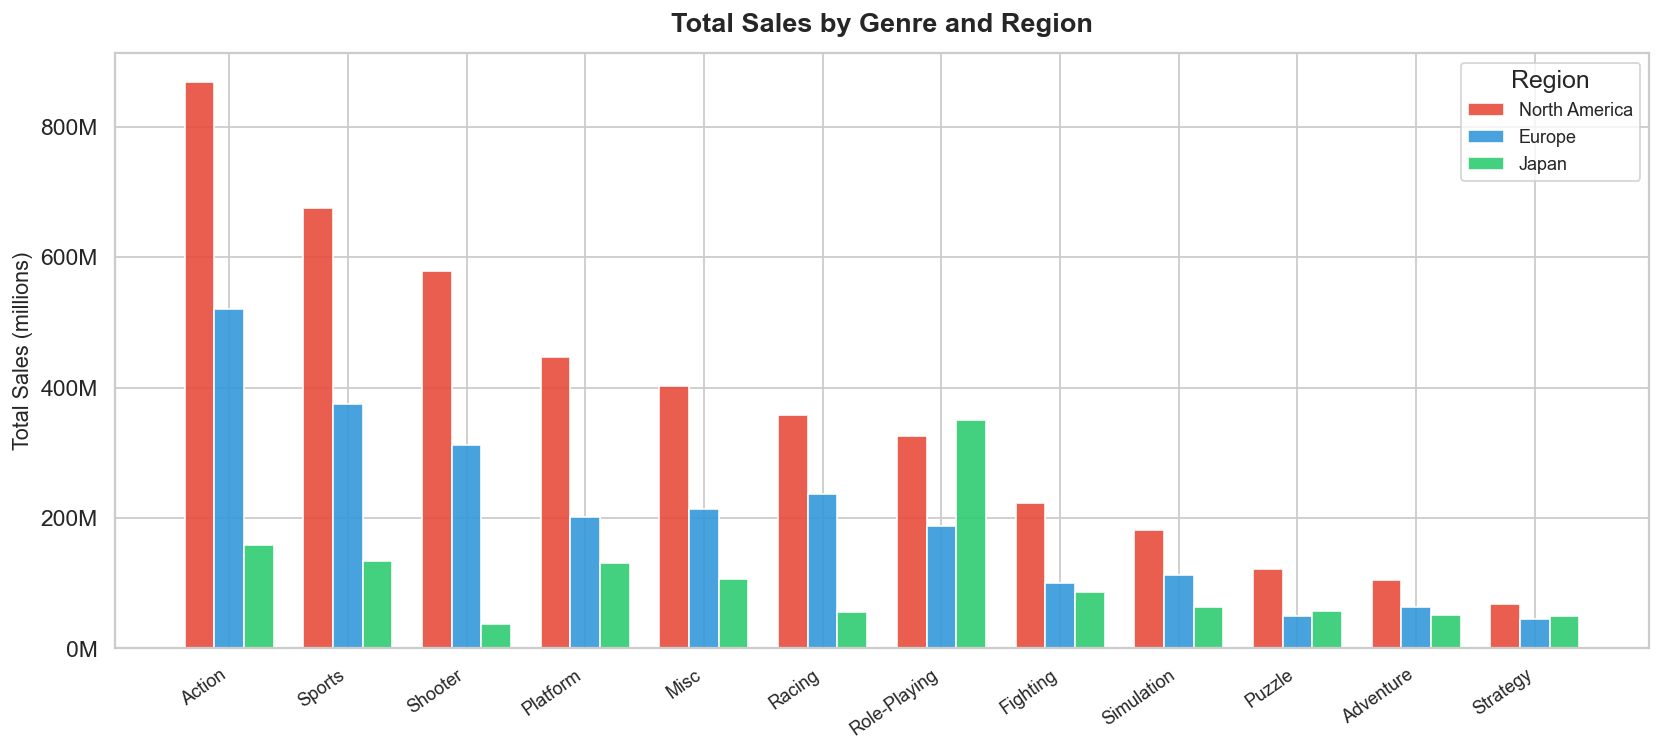

In [194]:
reg_genre_abs = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
reg_genre_abs.columns = ['North America', 'Europe', 'Japan']
reg_genre_abs = reg_genre_abs.sort_values('North America', ascending=False)

x      = np.arange(len(reg_genre_abs))
width  = 0.25
colors = ['#E74C3C', '#3498DB', '#2ECC71']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color) in enumerate(zip(reg_genre_abs.columns, colors)):
    ax.bar(x + i * width, reg_genre_abs[col], width,
           label=col, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(reg_genre_abs.index, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Total Sales (millions)', fontsize=12)
ax.set_title('Total Sales by Genre and Region', fontsize=15, fontweight='bold', pad=12)
ax.legend(title='Region', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
plt.tight_layout()
plt.show()

# RQ3  Publisher Market Concentration

In [195]:
pub = df.groupby('Publisher').agg(
    Total_Sales = ('Global_Sales', 'sum'),
    Num_Games   = ('Name',         'count'),
    Avg_Sales   = ('Global_Sales', 'mean'),
    First_Year  = ('Year',         'min'),
    Last_Year   = ('Year',         'max')
).sort_values('Total_Sales', ascending=False)
pub['Lifespan'] = pub['Last_Year'] - pub['First_Year']

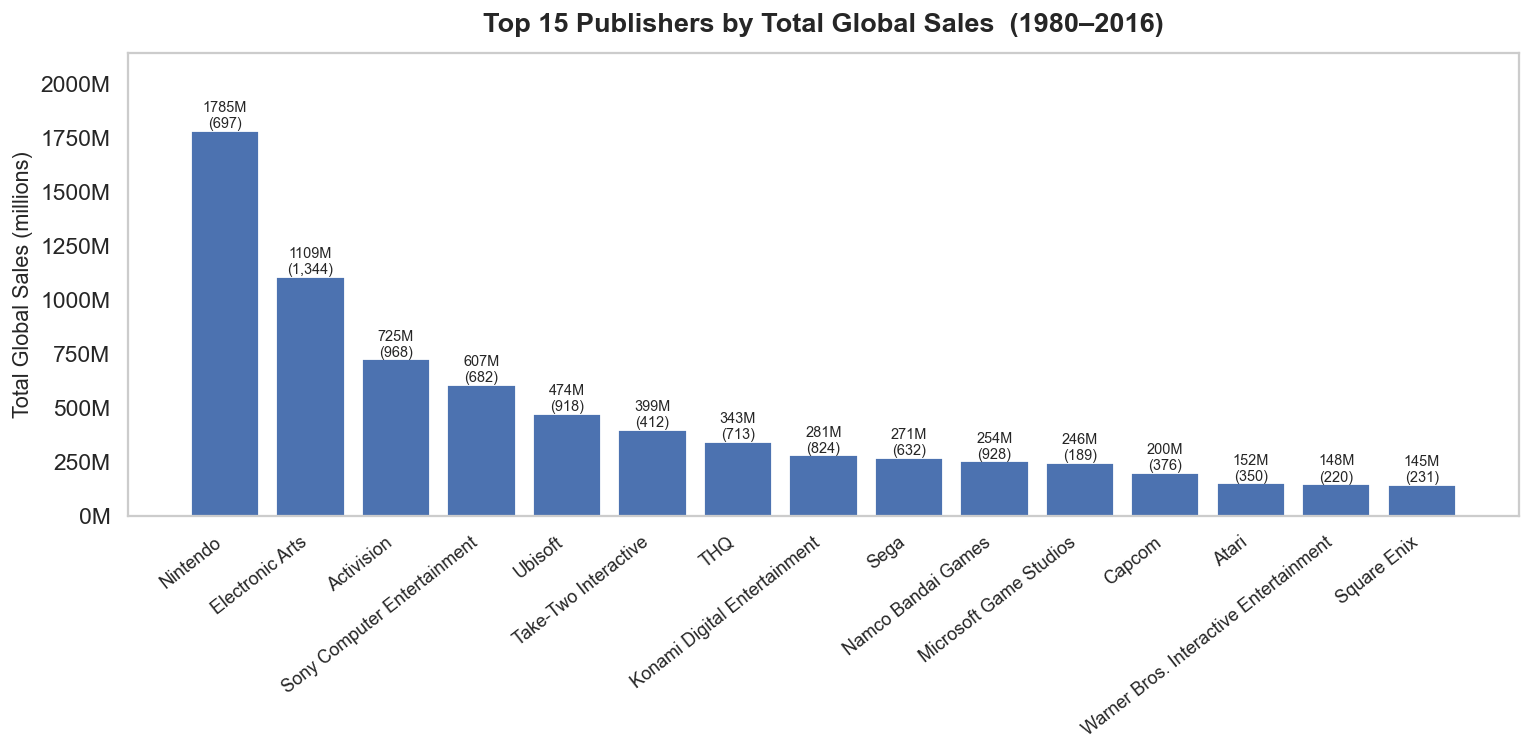

In [196]:
top15 = pub.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(top15)), top15['Total_Sales'].values)
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.index, rotation=38, ha='right', fontsize=10)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 15 Publishers by Total Global Sales  (1980–2016)',
             fontsize=15, fontweight='bold', pad=12)
for i, (val, games) in enumerate(zip(top15['Total_Sales'], top15['Num_Games'])):
    ax.text(i, val + 12, f'{val:.0f}M\n({games:,})', ha='center', fontsize=8)
ax.set_ylim(0, top15['Total_Sales'].max() * 1.20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
ax.grid(False)
plt.tight_layout()
plt.show()

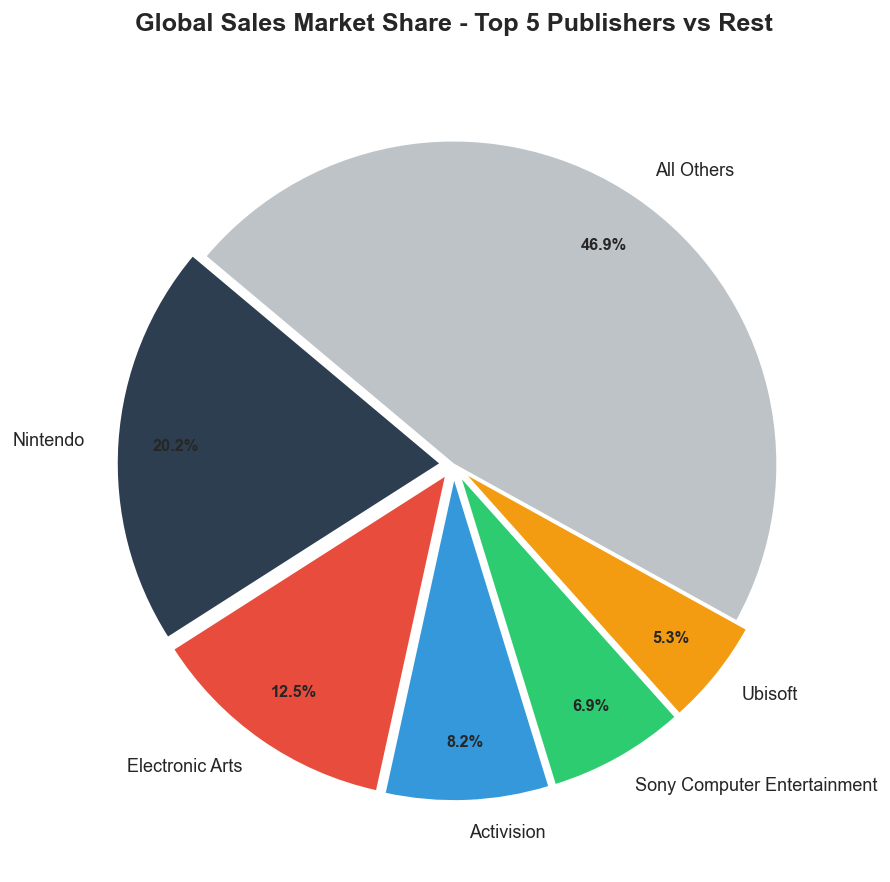

In [197]:
top5_sales  = pub.head(5)['Total_Sales']
rest_sales  = pub.iloc[5:]['Total_Sales'].sum()
pie_labels  = list(top5_sales.index) + ['All Others']
pie_values  = list(top5_sales.values) + [rest_sales]
pie_colors  = PALETTE[:5] + ['#BDC3C7']
explode     = [0.04] * 5 + [0]

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', explode=explode,
    startangle=140, pctdistance=0.82,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Global Sales Market Share - Top 5 Publishers vs Rest',
             fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()



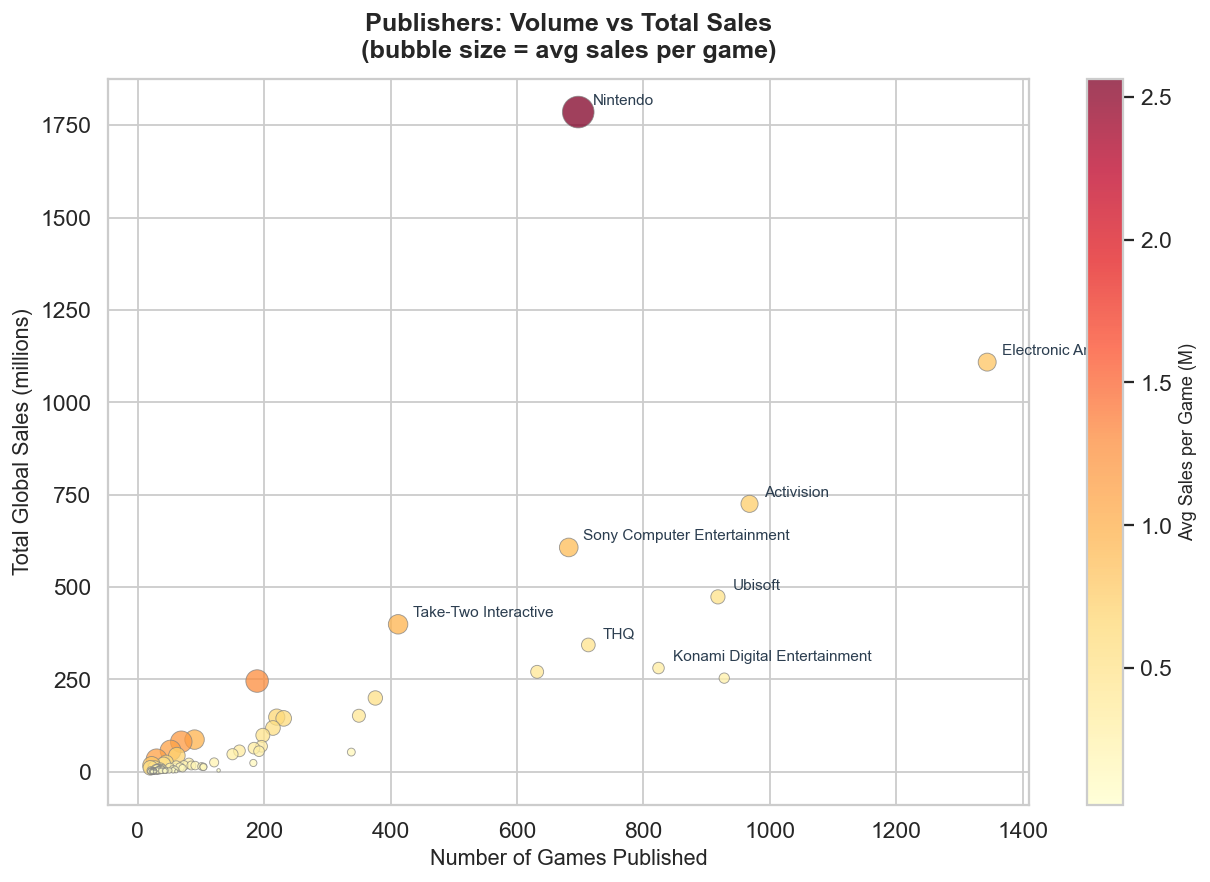

In [198]:
pub_plot = pub[pub['Num_Games'] >= 20].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    pub_plot['Num_Games'], pub_plot['Total_Sales'],
    s=pub_plot['Avg_Sales'] * 120,        # bubble size = avg sales
    c=pub_plot['Avg_Sales'],
    cmap='YlOrRd', alpha=0.75, edgecolors='grey', linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Avg Sales per Game (M)', fontsize=10)

# label top publishers
for pub_name, row in pub_plot.nlargest(8, 'Total_Sales').iterrows():
    ax.annotate(pub_name,
                xy=(row['Num_Games'], row['Total_Sales']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=8.5, color='#2C3E50')

ax.set_xlabel('Number of Games Published', fontsize=12)
ax.set_ylabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Publishers: Volume vs Total Sales\n(bubble size = avg sales per game)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


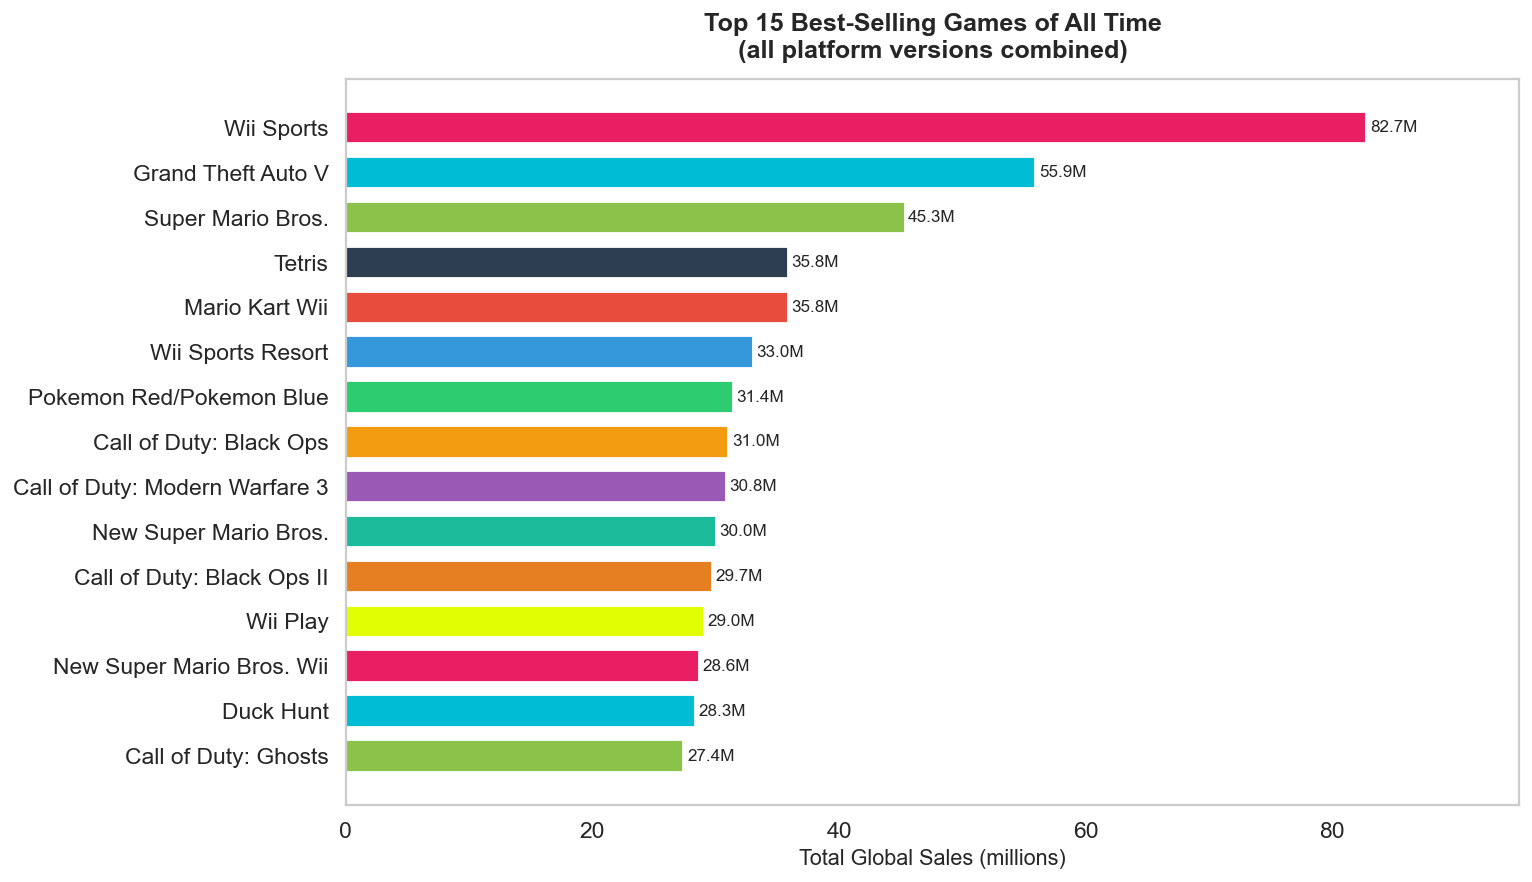

In [199]:
# RQ1 — What are the best-selling games?   
best_games = df.groupby('Name').agg(
    Global_Sales=('Global_Sales','sum'),
    NA_Sales=('NA_Sales','sum'),
    EU_Sales=('EU_Sales','sum'),
    JP_Sales=('JP_Sales','sum'),
    Genre=('Genre','first'),
    Publisher=('Publisher','first')
).sort_values('Global_Sales', ascending=False)


fig, ax = plt.subplots(figsize=(12, 7))
top15 = best_games.head(15).sort_values('Global_Sales')
colors_bar = PALETTE[:15]
bars = ax.barh(top15.index, top15['Global_Sales'], color=colors_bar[::-1],
               edgecolor='white', height=0.7)
for bar, val in zip(bars, top15['Global_Sales']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9.5)
ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top 15 Best-Selling Games of All Time\n(all platform versions combined)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, top15['Global_Sales'].max() * 1.15)
ax.grid(False)
plt.tight_layout()
plt.show()

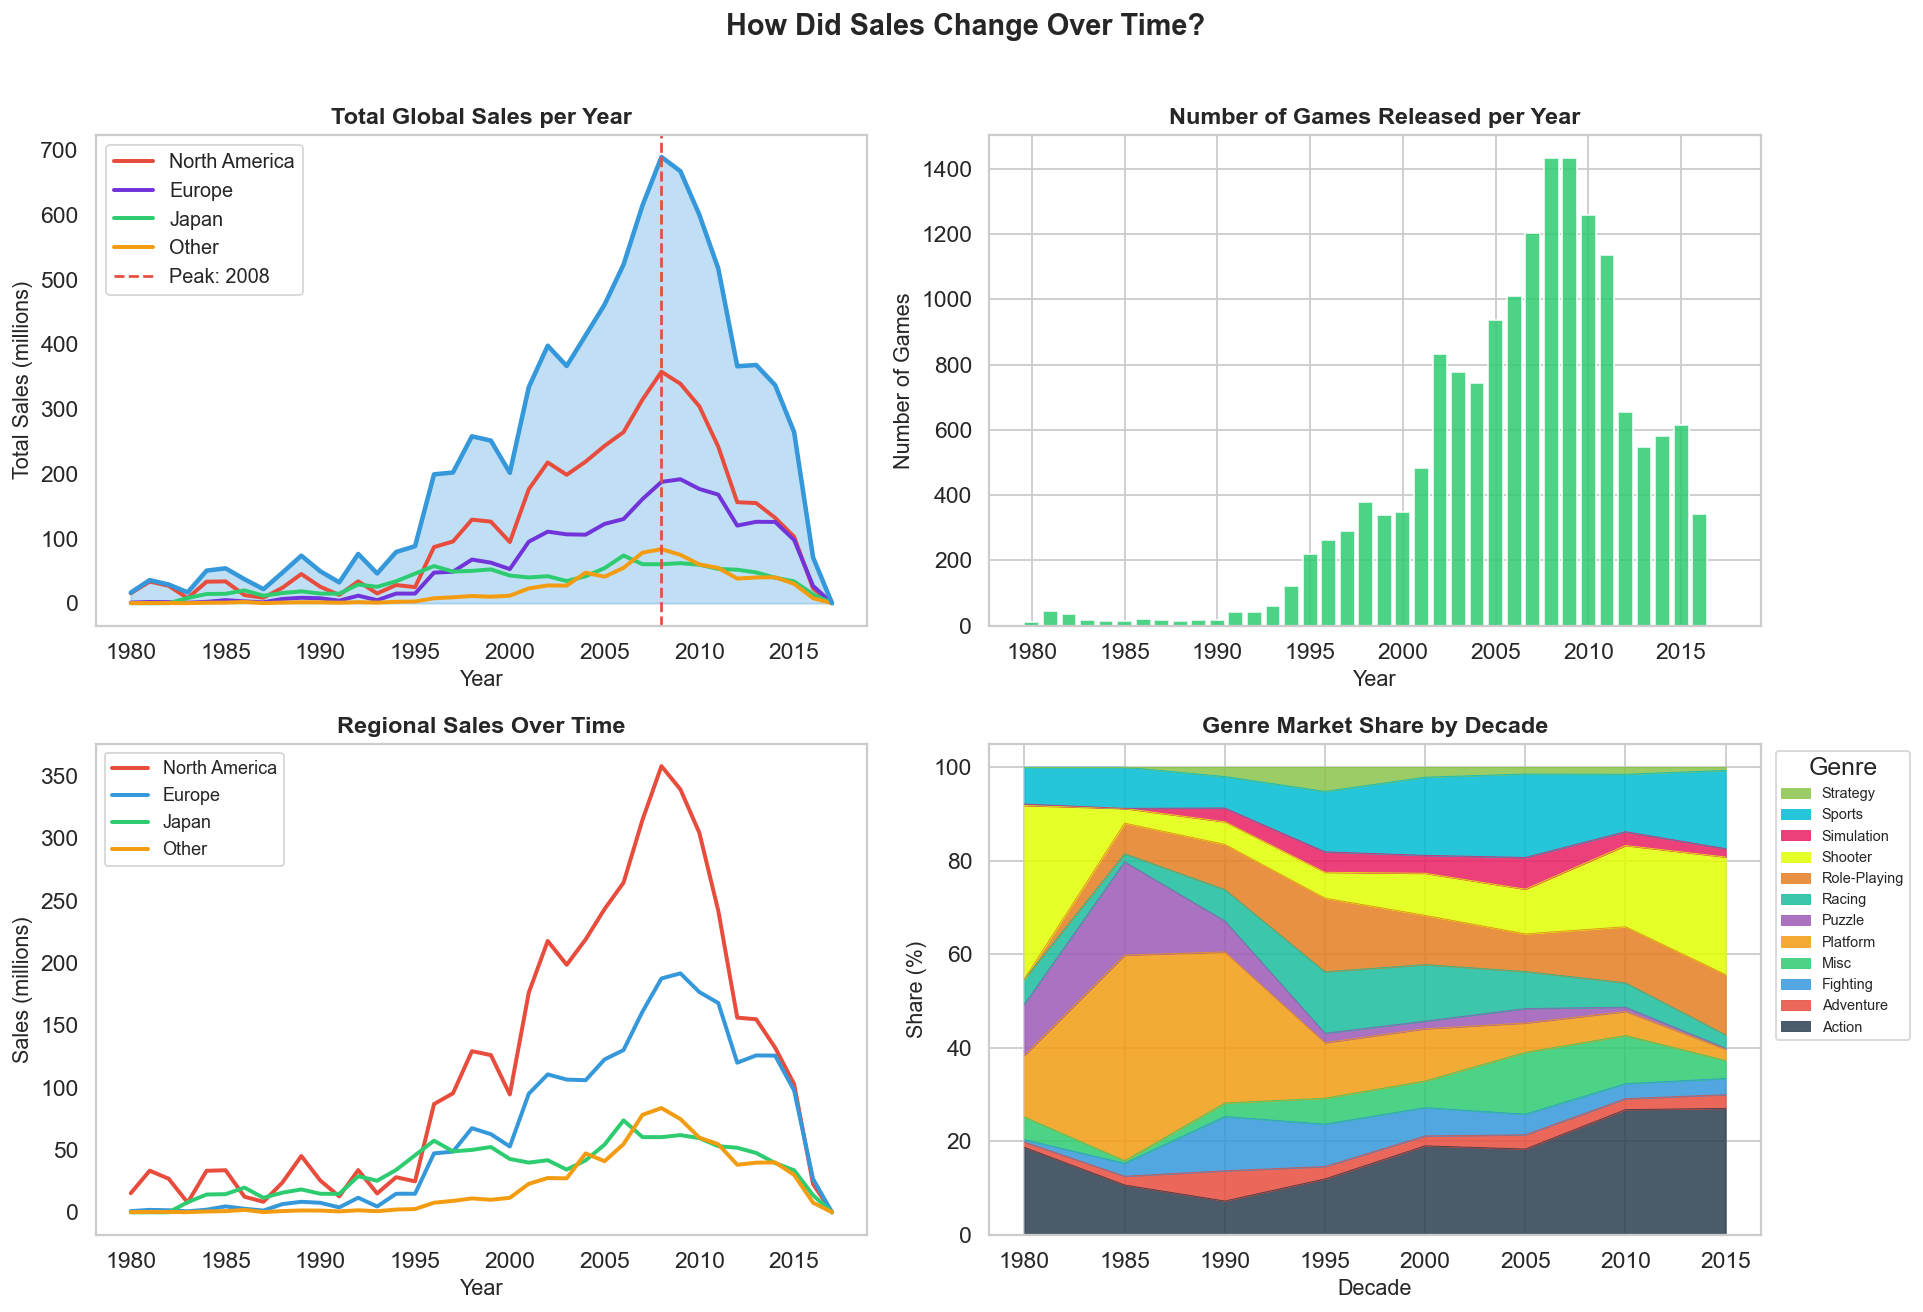

In [200]:
# RQ2 — How did sales change over the years?   
yearly = df.groupby('Year').agg(
    Total_Sales=('Global_Sales','sum'),
    Num_Games=('Name','count'),
    Avg_Sales=('Global_Sales','mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total sales per year
ax = axes[0,0]
ax.fill_between(yearly['Year'], yearly['Total_Sales'],
                alpha=0.3, color='#3498DB')
reg_yearly = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
colors_r = ['#E74C3C',"#7134DB",'#2ECC71','#F39C12']
labels_r = ['North America','Europe','Japan','Other']
for col, color, label in zip(reg_yearly.columns, colors_r, labels_r):
    ax.plot(reg_yearly.index, reg_yearly[col],
            color=color, linewidth=2.2, label=label)
ax.plot(yearly['Year'], yearly['Total_Sales'],
        color='#3498DB', linewidth=2.5)
ax.set_title('Total Global Sales per Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Sales (millions)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.grid(False)
peak_year = yearly.loc[yearly['Total_Sales'].idxmax(), 'Year']
ax.axvline(peak_year, color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Peak: {peak_year}')
ax.legend(fontsize=11)

# Games released per year
ax = axes[0,1]
ax.bar(yearly['Year'], yearly['Num_Games'],
       color='#2ECC71', edgecolor='white', alpha=0.85)
ax.set_title('Number of Games Released per Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

# Regional sales over time
ax = axes[1,0]
reg_yearly = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
colors_r = ['#E74C3C','#3498DB','#2ECC71','#F39C12']
labels_r = ['North America','Europe','Japan','Other']
for col, color, label in zip(reg_yearly.columns, colors_r, labels_r):
    ax.plot(reg_yearly.index, reg_yearly[col],
            color=color, linewidth=2.2, label=label)
ax.set_title('Regional Sales Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales (millions)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.grid(False)
ax.legend(fontsize=10)

# Genre share over decades (stacked area)
ax = axes[1,1]
decade_genre = df.groupby(['5_Year_period','Genre'])['Global_Sales'].sum().unstack(fill_value=0)
decade_genre_pct = decade_genre.div(decade_genre.sum(axis=1), axis=0) * 100
decade_genre_pct.plot(kind='area', stacked=True, ax=ax,
                      color=PALETTE[:12], alpha=0.85, linewidth=0.5)
ax.set_title('Genre Market Share by Decade', fontsize=13, fontweight='bold')
ax.set_ylabel('Share (%)', fontsize=12)
ax.set_xlabel('Decade', fontsize=12)
 #labels starts upside down so reversed the order of colors
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],title='Genre', bbox_to_anchor=(1.01,1), fontsize=8,)
ax.set_xticks(decade_genre_pct.index)
ax.set_xticklabels([f'{d}' for d in decade_genre_pct.index])

plt.suptitle(' How Did Sales Change Over Time?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



              Total_Sales  Num_Games  Share_%
Genre                                        
Action            1734.56       3258     19.6
Sports            1319.42       2306     14.9
Shooter           1032.62       1285     11.7
Role-Playing       923.83       1470     10.4
Platform           830.16        876      9.4
Misc               798.40       1691      9.0
Racing             727.98       1226      8.2
Fighting           447.05        837      5.0
Simulation         389.98        848      4.4
Puzzle             242.21        570      2.7
Adventure          238.28       1276      2.7
Strategy           173.27        670      2.0

ANOVA:          F=18.16, p=1.42e-36


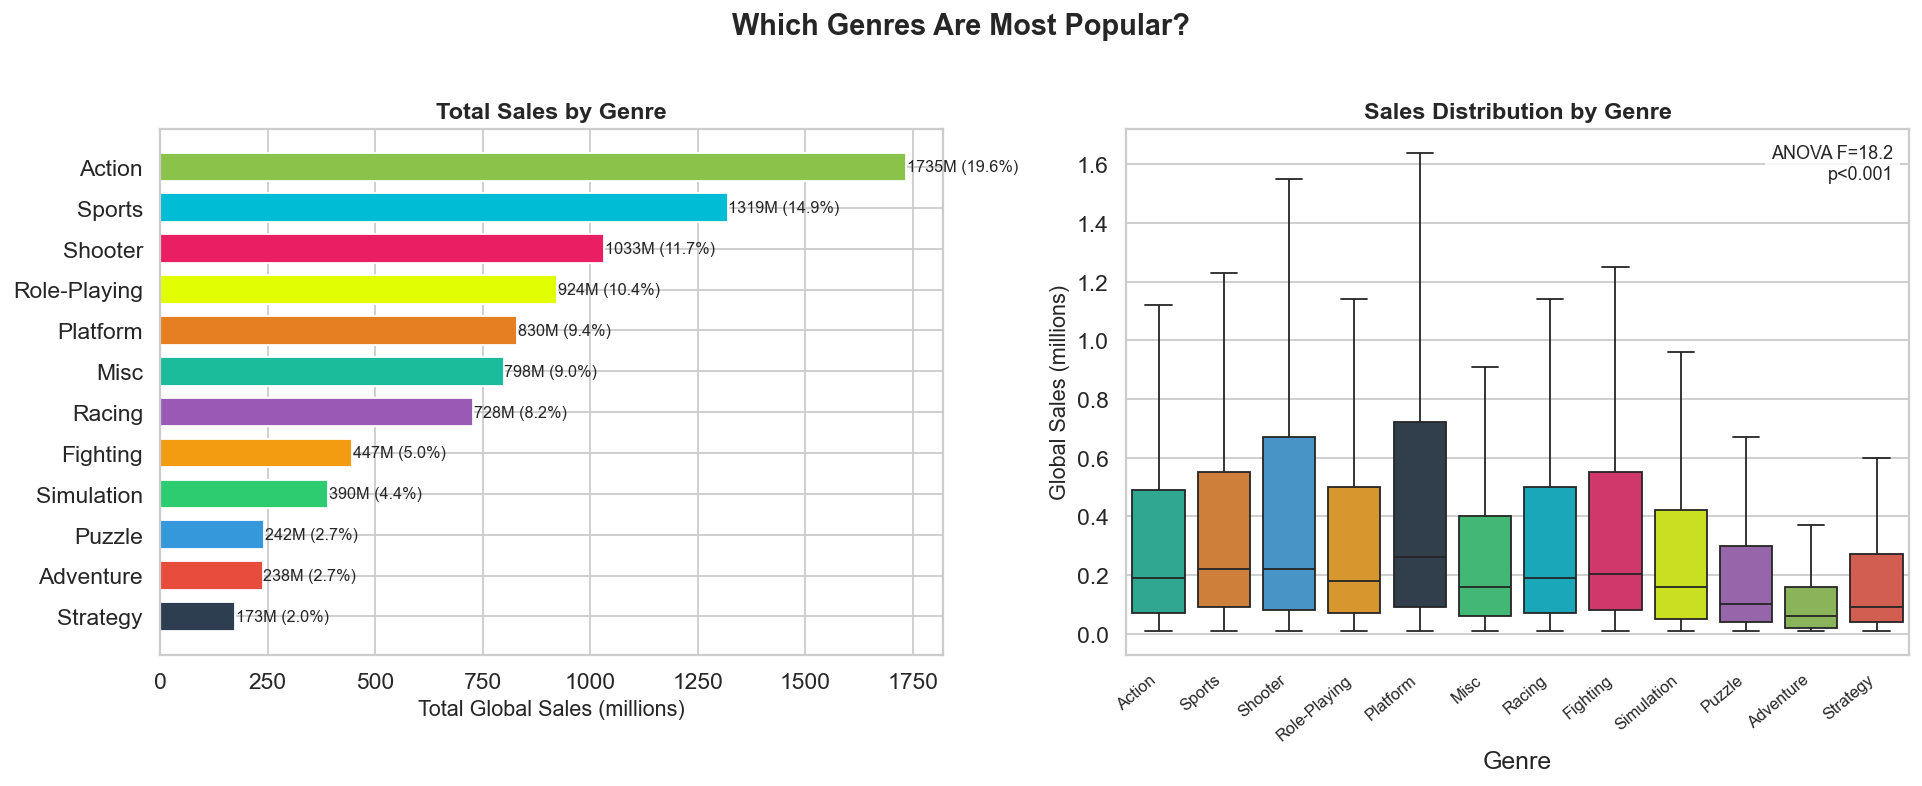

In [201]:
#RQ3 — Which genres are most popular?               
genre_stats = df.groupby('Genre').agg(
    Total_Sales=('Global_Sales','sum'),
    Num_Games=('Name','count')
).sort_values('Total_Sales', ascending=False)
genre_stats['Share_%'] = (genre_stats['Total_Sales'] /
                           genre_stats['Total_Sales'].sum() * 100).round(1)
print(genre_stats.round(2).to_string())

# ANOVA test — do genres differ in sales?
groups = [g['Global_Sales'].values for _, g in df.groupby('Genre')]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nANOVA:          F={f_stat:.2f}, p={p_anova:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total sales bar
ax = axes[0]
gs_sorted = genre_stats['Total_Sales'].sort_values()
ax.barh(gs_sorted.index, gs_sorted.values,
        color=PALETTE[:len(gs_sorted)], edgecolor='white', height=0.7)
for i, (idx, val) in enumerate(gs_sorted.items()):
    ax.text(val+2, i, f'{val:.0f}M ({genre_stats.loc[idx,"Share_%"]}%)',
            va='center', fontsize=9)
ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Total Sales by Genre', fontsize=13, fontweight='bold')

# Box plot
ax = axes[1]
genre_order = genre_stats.index.tolist()
df_clip = df[df['Global_Sales'] < df['Global_Sales'].quantile(0.99)]
sns.boxplot(data=df_clip, x='Genre', y='Global_Sales',
            order=genre_order, palette=PALETTE[:12],
            ax=ax, hue='Genre', legend=False,showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Global Sales (millions)', fontsize=12)
ax.set_title('Sales Distribution by Genre',
             fontsize=13, fontweight='bold')
ax.text(0.98, 0.97, f'ANOVA F={f_stat:.1f}\np<0.001',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.suptitle('Which Genres Are Most Popular?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Chi-Square (publisher × platform_family):
  χ² = 4561.52, dof=72, p=0.00e+00
  Cramér's V = 0.265 (strong association)


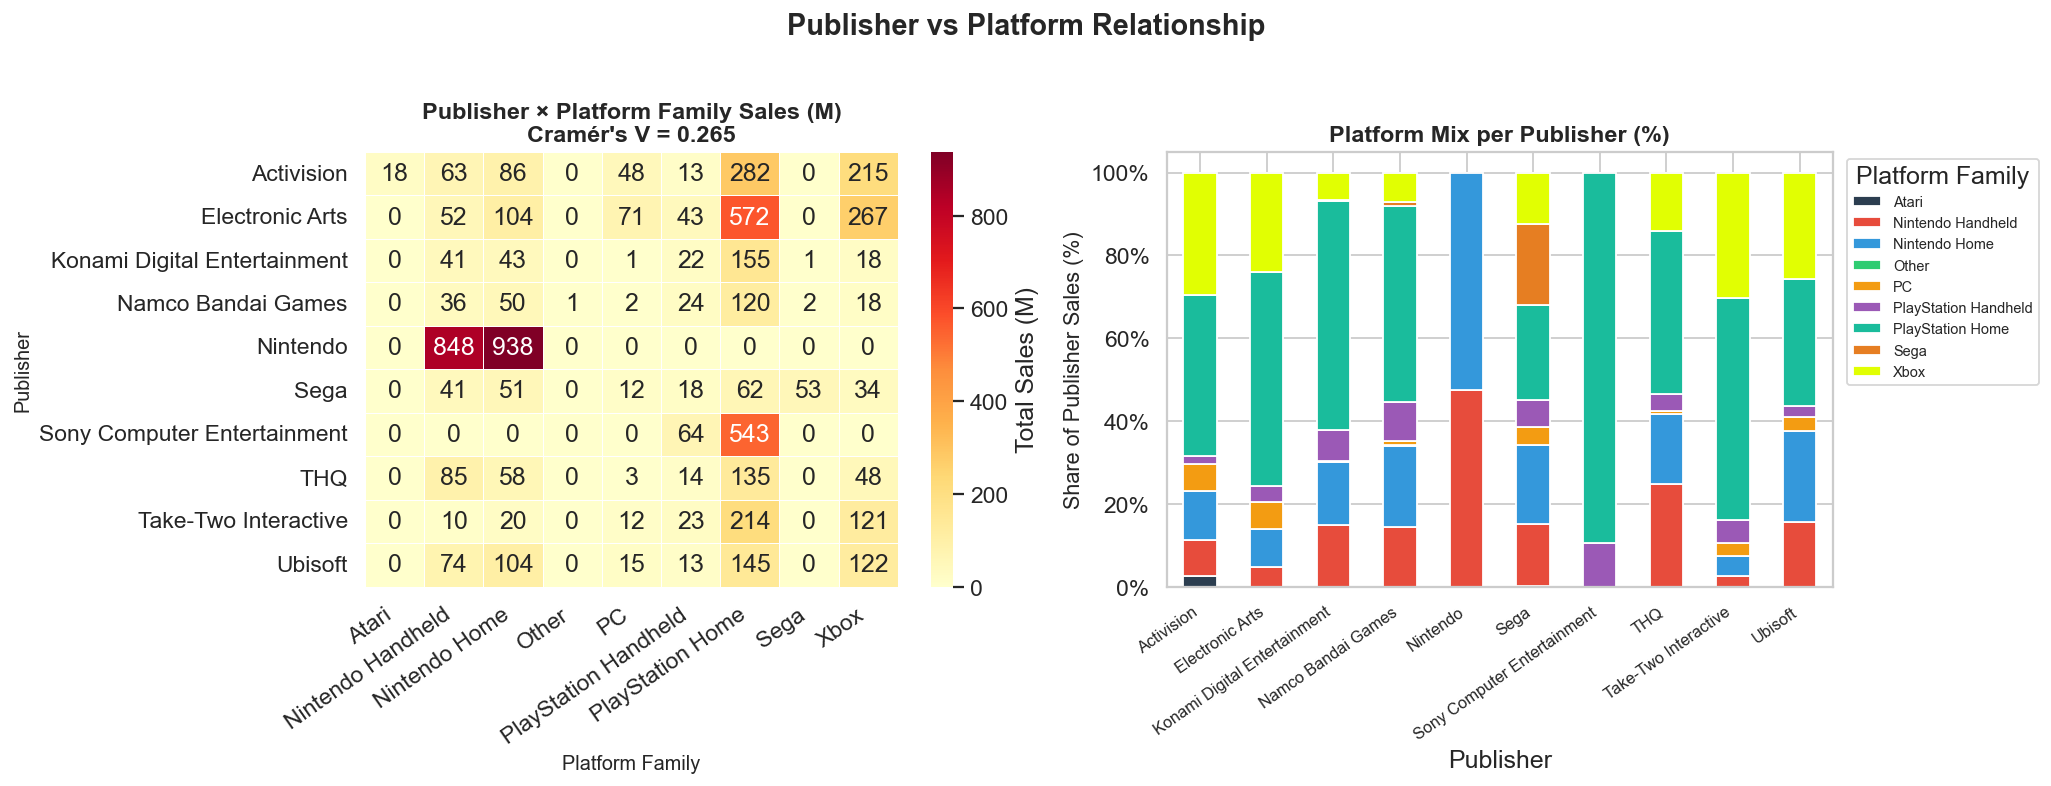

In [202]:
# RQ4 — Is there a relationship between publishers and platforms?       
top10_pub = df['Publisher'].value_counts().head(10).index.tolist()
df_top = df[df['Publisher'].isin(top10_pub)].copy()
contingency_pp = pd.crosstab(df_top['Publisher'], df_top['Platform_Family'])
chi2_pp, p_pp, dof_pp, _ = stats.chi2_contingency(contingency_pp)
n_pp = contingency_pp.values.sum()
cramers_pp = np.sqrt(chi2_pp / (n_pp * (min(contingency_pp.shape) - 1)))

print(f"Chi-Square (publisher × platform_family):")
print(f"  χ² = {chi2_pp:.2f}, dof={dof_pp}, p={p_pp:.2e}")
print(f"  Cramér's V = {cramers_pp:.3f} (strong association)")

# Sales heatmap: top 8 publishers × platform families
pivot_pp = df_top.pivot_table(
    values='Global_Sales', index='Publisher',
    columns='Platform_Family', aggfunc='sum', fill_value=0
)
# keep only platform families with data
pivot_pp = pivot_pp.loc[:, pivot_pp.sum() > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.heatmap(pivot_pp, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            cbar_kws={'label':'Total Sales (M)'})
ax.set_title(f'Publisher × Platform Family Sales (M)\nCramér\'s V = {cramers_pp:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Platform Family', fontsize=11)
ax.set_ylabel('Publisher', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')

# Stacked bar: platform family mix per publisher
ax = axes[1]
pivot_pct = pivot_pp.div(pivot_pp.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=ax,
               color=PALETTE[:len(pivot_pct.columns)], edgecolor='white')
ax.set_ylabel('Share of Publisher Sales (%)', fontsize=12)
ax.set_title('Platform Mix per Publisher (%)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.legend(title='Platform Family', bbox_to_anchor=(1.01,1), fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

plt.suptitle('Publisher vs Platform Relationship',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


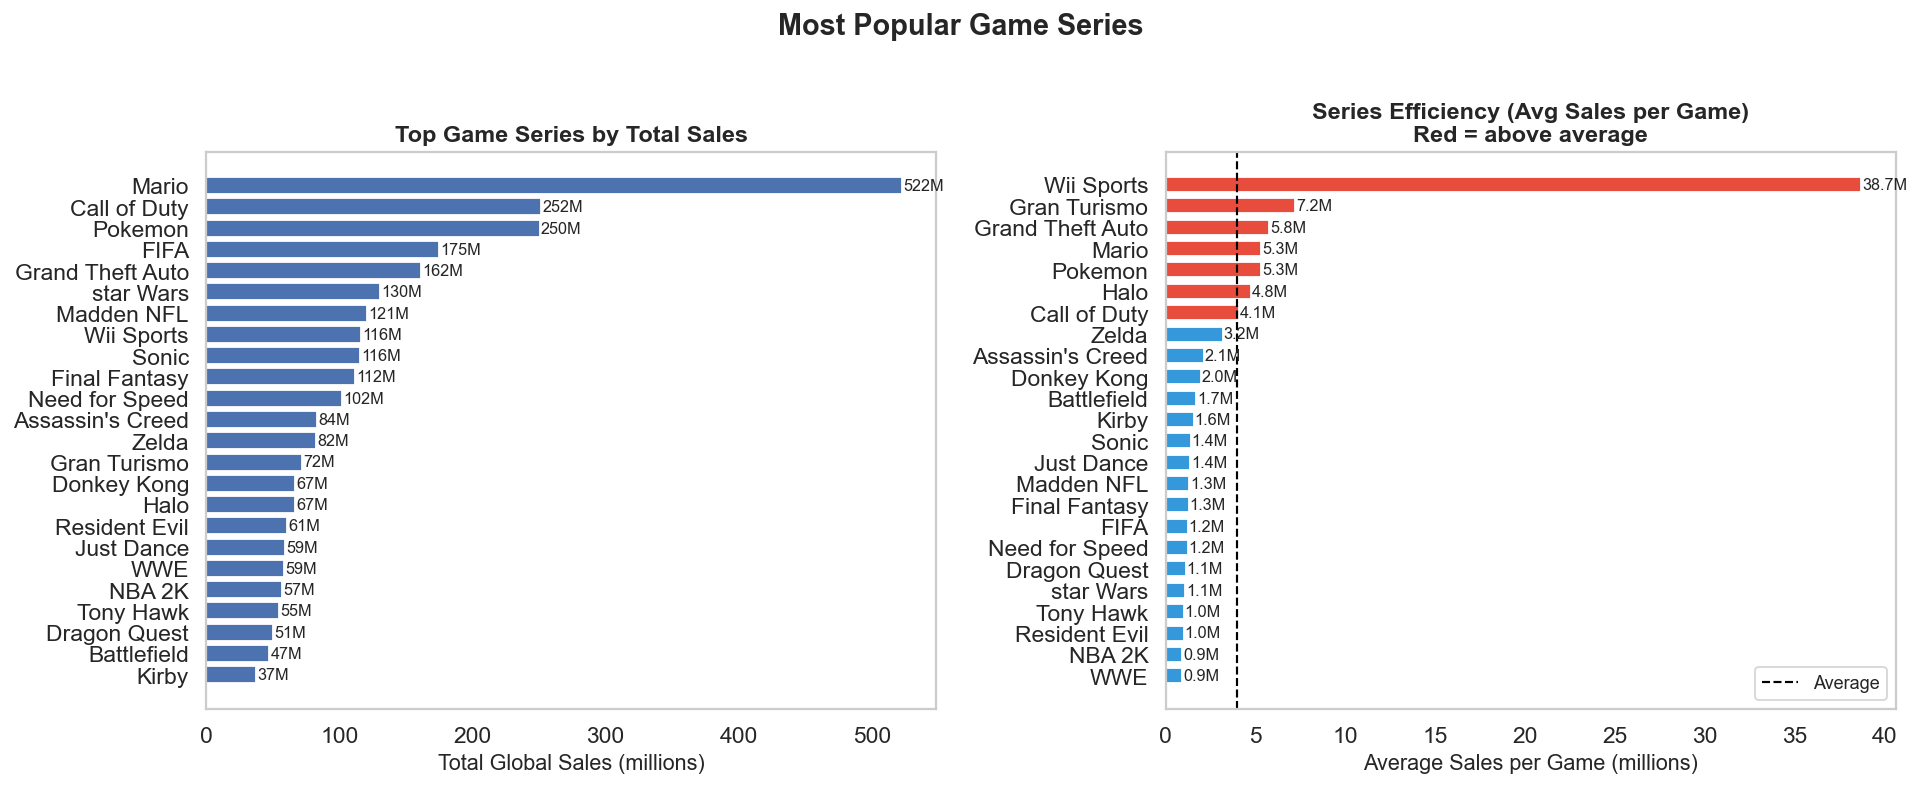

In [203]:
# RQ6 — Which game series is the most popular?            
series_stats = df[df['Game_Series'] != 'Standalone'].groupby('Game_Series').agg(
    Total_Sales=('Global_Sales','sum'),
    Num_Games=('Name','count'),
    Avg_Per_Game=('Global_Sales','mean'),
    First_Year=('Year','min'),
    Last_Year=('Year','max')
).sort_values('Total_Sales', ascending=False)
series_stats['Lifespan'] = series_stats['Last_Year'] - series_stats['First_Year']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total sales by series
ax = axes[0]
ax.grid(False)
ss_sorted = series_stats['Total_Sales'].sort_values()
bars = ax.barh(ss_sorted.index, ss_sorted.values)
for bar, val in zip(bars, ss_sorted.values):
    ax.text(val+1, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}M', va='center', fontsize=9)
ax.set_xlabel('Total Global Sales (millions)', fontsize=12)
ax.set_title('Top Game Series by Total Sales', fontsize=13, fontweight='bold')

# Avg sales per game by series (efficiency)
ax = axes[1]
avg_sorted = series_stats['Avg_Per_Game'].sort_values()
colors_a   = ['#E74C3C' if v > series_stats['Avg_Per_Game'].mean()
               else '#3498DB' for v in avg_sorted]
bars = ax.barh(avg_sorted.index, avg_sorted.values,
               color=colors_a, edgecolor='white', height=0.7)
ax.axvline(series_stats['Avg_Per_Game'].mean(), color='black',
           linewidth=1.2, linestyle='--', label='Average')
for bar, val in zip(bars, avg_sorted.values):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9)
ax.set_xlabel('Average Sales per Game (millions)', fontsize=12)
ax.set_title('Series Efficiency (Avg Sales per Game)\nRed = above average',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(False)

plt.suptitle('Most Popular Game Series',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

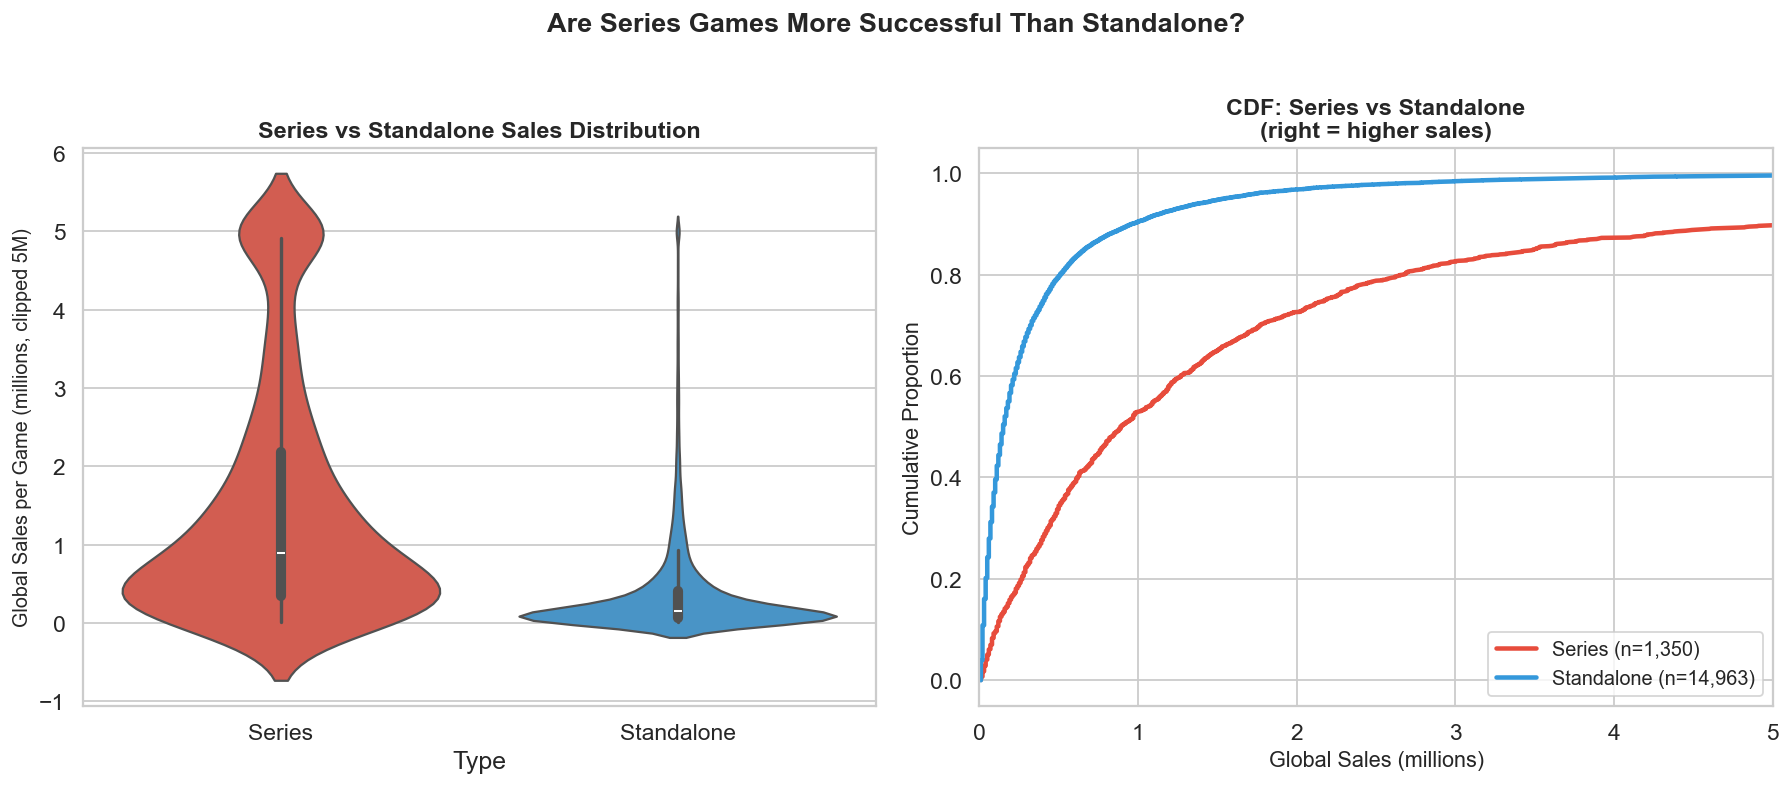

In [204]:
# RQ7 — Are game series more successful than individual (standalone) games? 
df['Is_Series'] = df['Game_Series'] != 'Standalone'
series_sales    = df[df['Is_Series']]['Global_Sales']
standalone_sales= df[~df['Is_Series']]['Global_Sales']

u_stat, p_mw = stats.mannwhitneyu(series_sales, standalone_sales,
                                   alternative='greater')
n1, n2 = len(series_sales), len(standalone_sales)
effect_r = 1 - (2*u_stat)/(n1*n2)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin
ax = axes[0]
plot_df = pd.DataFrame({
    'Sales': pd.concat([series_sales.clip(upper=5), standalone_sales.clip(upper=5)]),
    'Type': ['Series']*n1 + ['Standalone']*n2
})
sns.violinplot(data=plot_df, x='Type', y='Sales',
               palette=['#E74C3C','#3498DB'], ax=ax, inner='box')
ax.set_ylabel('Global Sales per Game (millions, clipped 5M)', fontsize=11)
ax.set_title('Series vs Standalone Sales Distribution',
             fontsize=13, fontweight='bold')


# CDF
ax = axes[1]
for vals, color, label, n in [(series_sales,'#E74C3C','Series',n1),
                               (standalone_sales,'#3498DB','Standalone',n2)]:
    sv  = np.sort(vals)
    cdf = np.arange(1, len(sv)+1) / len(sv)
    ax.plot(sv, cdf, color=color, linewidth=2.5, label=f'{label} (n={n:,})')
ax.set_xlim(0, 5)
ax.set_xlabel('Global Sales (millions)', fontsize=12)
ax.set_ylabel('Cumulative Proportion', fontsize=12)
ax.set_title('CDF: Series vs Standalone\n(right = higher sales)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.suptitle('Are Series Games More Successful Than Standalone?',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



##### This chart reveals that video games belonging to an established Series are significantly more successful and "safer" investments than Standalone titles. The blue line (Standalone) climbs vertically almost immediately, showing that the vast majority of these games fail to gain traction and settle at very low sales numbers. In contrast, the red line (Series) moves much further to the right, proving that these games are far more likely to cross major sales milestones like 1, 2, or 3 million units. Essentially, while a standalone game is a high-risk gamble where most titles sell very little, a game in a series benefits from a "brand cushion" that virtually guarantees higher typical sales and a much better chance of becoming a major hit.

## Statistical tests 

##### Q1: Is genre preference independent of region? 


Genre Independence from Region  (Chi-Square)
  Chi-Square statistic : 2086.63
  Degrees of freedom   : 22
  p-value              : 0.0000e+00
  Cramér's V           : 0.2529  (moderate association)
  Result               : SIGNIFICANT ✓


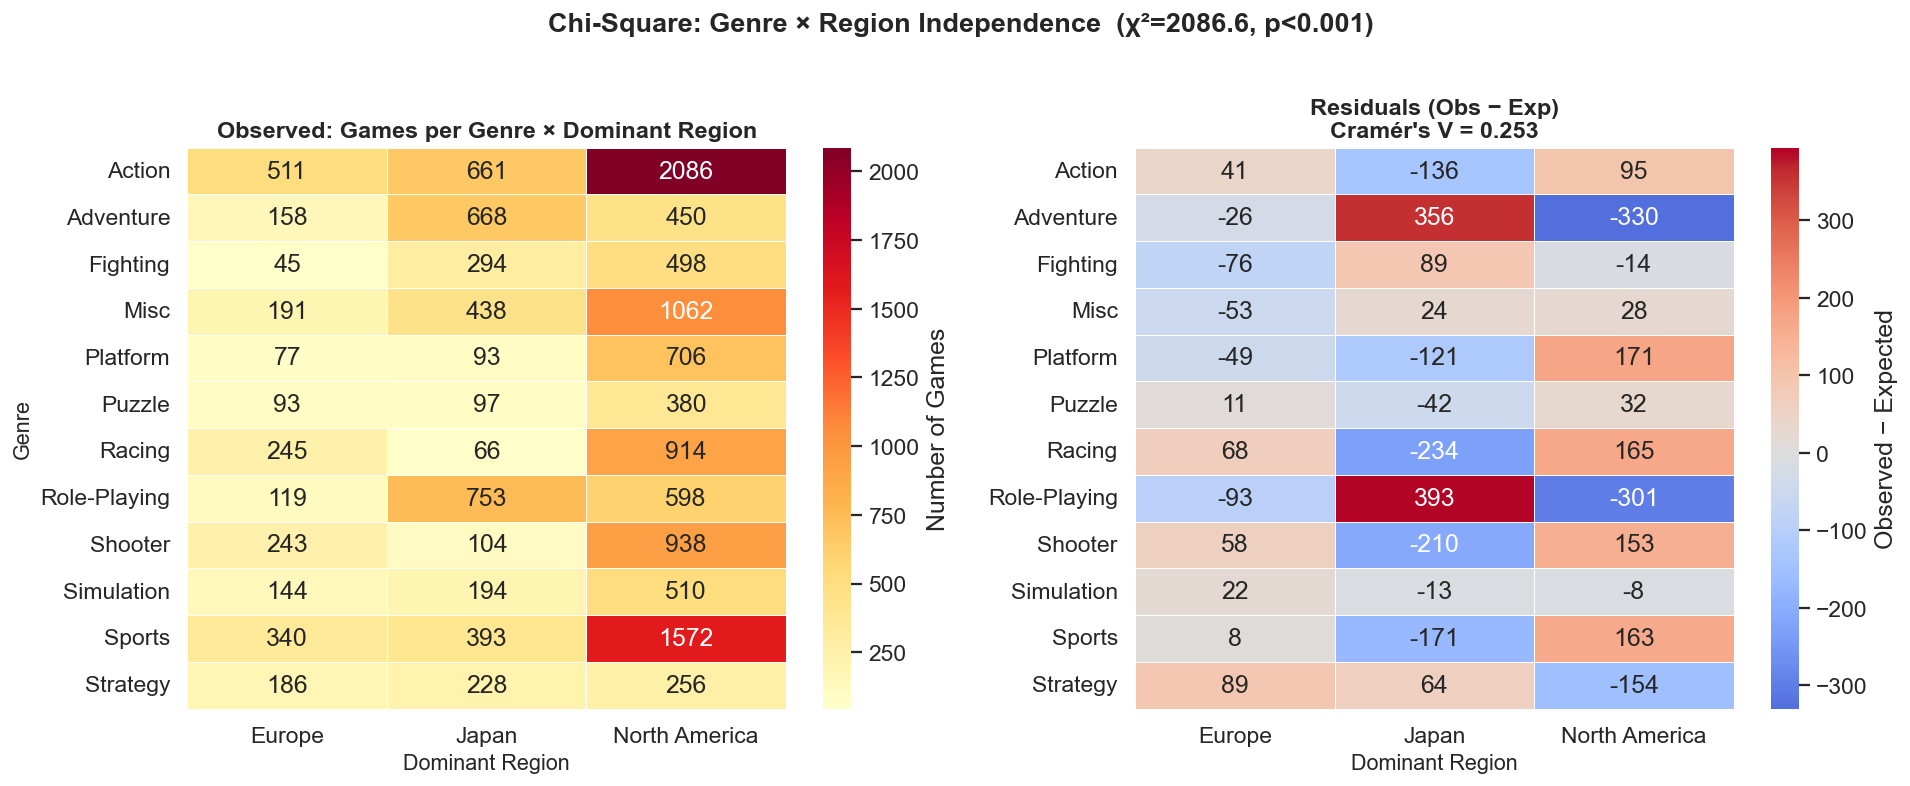

In [205]:

# we perform Chi-Square Test here to test if genre preference is independent of region Because Both variables are categorical (genre × region)
# H0     : Genre choice is independent of region
# H1     : Genre preference depends on region
results = {}
print("=" * 60)
print("Genre Independence from Region  (Chi-Square)")
print("=" * 60)

# classify each game's "dominant region"
reg_cols = ['NA_Sales','EU_Sales','JP_Sales']
df['Dom_Region'] = df[reg_cols].idxmax(axis=1).map({
    'NA_Sales':'North America',
    'EU_Sales':'Europe',
    'JP_Sales':'Japan'
})
# only keep games where dominant region is clear (>0)
df_chi = df[df[reg_cols].max(axis=1) > 0].copy()

contingency = pd.crosstab(df_chi['Genre'], df_chi['Dom_Region'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

# Cramér's V (effect size for chi-square)
n_chi = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_chi * (min(contingency.shape) - 1)))

print(f"  Chi-Square statistic : {chi2:.2f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {p_chi:.4e}")
print(f"  Cramér's V           : {cramers_v:.4f}  "
      f"({'strong' if cramers_v>0.3 else 'moderate' if cramers_v>0.1 else 'weak'} association)")
print(f"  Result               : {'SIGNIFICANT ✓' if p_chi<0.05 else 'Not significant'}")
results['RQ-T4'] = {'test':'Chi-Square','stat':chi2,'p':p_chi,'sig':p_chi<0.05}

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# heatmap of observed counts
ax = axes[0]
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            cbar_kws={'label':'Number of Games'})
ax.set_title('Observed: Games per Genre × Dominant Region',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dominant Region', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)

# residuals heatmap (observed - expected)
residuals = contingency.values - expected
res_df    = pd.DataFrame(residuals, index=contingency.index, columns=contingency.columns)
ax = axes[1]
sns.heatmap(res_df, annot=True, fmt='.0f', cmap='coolwarm',
            ax=ax, linewidths=0.5, center=0,
            cbar_kws={'label':'Observed − Expected'})
ax.set_title(f'Residuals (Obs − Exp)\nCramér\'s V = {cramers_v:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dominant Region', fontsize=12)
ax.set_ylabel('')

plt.suptitle(f'Chi-Square: Genre × Region Independence  (χ²={chi2:.1f}, p<0.001)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [208]:
"""
╔══════════════════════════════════════════════════════════════╗
║   COMPLETE ML ANALYSIS — VIDEO GAME SALES DATASET          ║
║                                                             ║
║   TASK 1 — K-Means Clustering   (regional market groups)   ║
║   TASK 2 — Random Forest        (blockbuster predictor)     ║
║   TASK 3 — Genre Predictor      (classify genre from sales) ║
║   TASK 4 — Anomaly Detection    (find outlier games)        ║
╚══════════════════════════════════════════════════════════════╝
"""


# series flag
series_kw = ['Mario','Pokemon','Call of Duty','Grand Theft Auto',
             'FIFA','Final Fantasy','Zelda','Sonic','Halo',
             "Assassin's Creed",'Madden','Gran Turismo','Need for Speed',
             'Resident Evil','Street Fighter','Battlefield','The Sims',
             'Donkey Kong','Dragon Quest','Kirby','Just Dance','WWE',
             'NBA 2K','Mortal Kombat','Tony Hawk','Star Wars','Smash Bros','sports wii']
df['Is_Series'] = df['Name'].str.contains(
    '|'.join(series_kw), case=False, na=False).astype(int)

# log-transform sales
for c in ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']:
    df[f'log_{c}'] = np.log1p(df[c])

# encode categoricals
le_genre = LabelEncoder()
le_plat  = LabelEncoder()
le_pub   = LabelEncoder()
df['genre_enc'] = le_genre.fit_transform(df['Genre'])
df['plat_enc']  = le_plat.fit_transform(df['Platform'])
df['pub_enc']   = le_pub.fit_transform(df['Publisher'])

# blockbuster label  (top 10 %)
thresh = df['Global_Sales'].quantile(0.90)
df['Blockbuster'] = (df['Global_Sales'] >= thresh).astype(int)

print(f"Dataset ready : {len(df):,} games")
print(f"Blockbuster threshold : {thresh:.2f} M  |  "
      f"{df['Blockbuster'].sum():,} blockbusters ({df['Blockbuster'].mean()*100:.1f} %)")



Dataset ready : 16,313 games
Blockbuster threshold : 1.23 M  |  1,632 blockbusters (10.0 %)



════════════════════════════════════════════════════════════
TASK 1 — K-MEANS CLUSTERING
════════════════════════════════════════════════════════════
  k=2  inertia=38917.6  silhouette=0.7569
  k=3  inertia=29805.8  silhouette=0.6348
  k=4  inertia=23904.8  silhouette=0.6466
  k=5  inertia=20044.4  silhouette=0.5911
  k=6  inertia=18006.6  silhouette=0.5589
  k=7  inertia=16030.7  silhouette=0.5115
  k=8  inertia=14588.4  silhouette=0.5125

  Best k by silhouette score : k = 2

  Cluster Profiles:
         Count  NA_mean  EU_mean  JP_mean  Other_mean  Global_mean  Global_med Top_Genre
Cluster                                                                                 
0        15314    0.154    0.072    0.055       0.023        0.304        0.15    Action
1          999    2.006    1.322    0.444       0.436        4.207        2.85    Action

  Cluster names assigned:
    Cluster 0 → 'Low-Sales Niche'  (15,314 games, avg=0.304M)
    Cluster 1 → 'Global Blockbusters'  (999 games, 

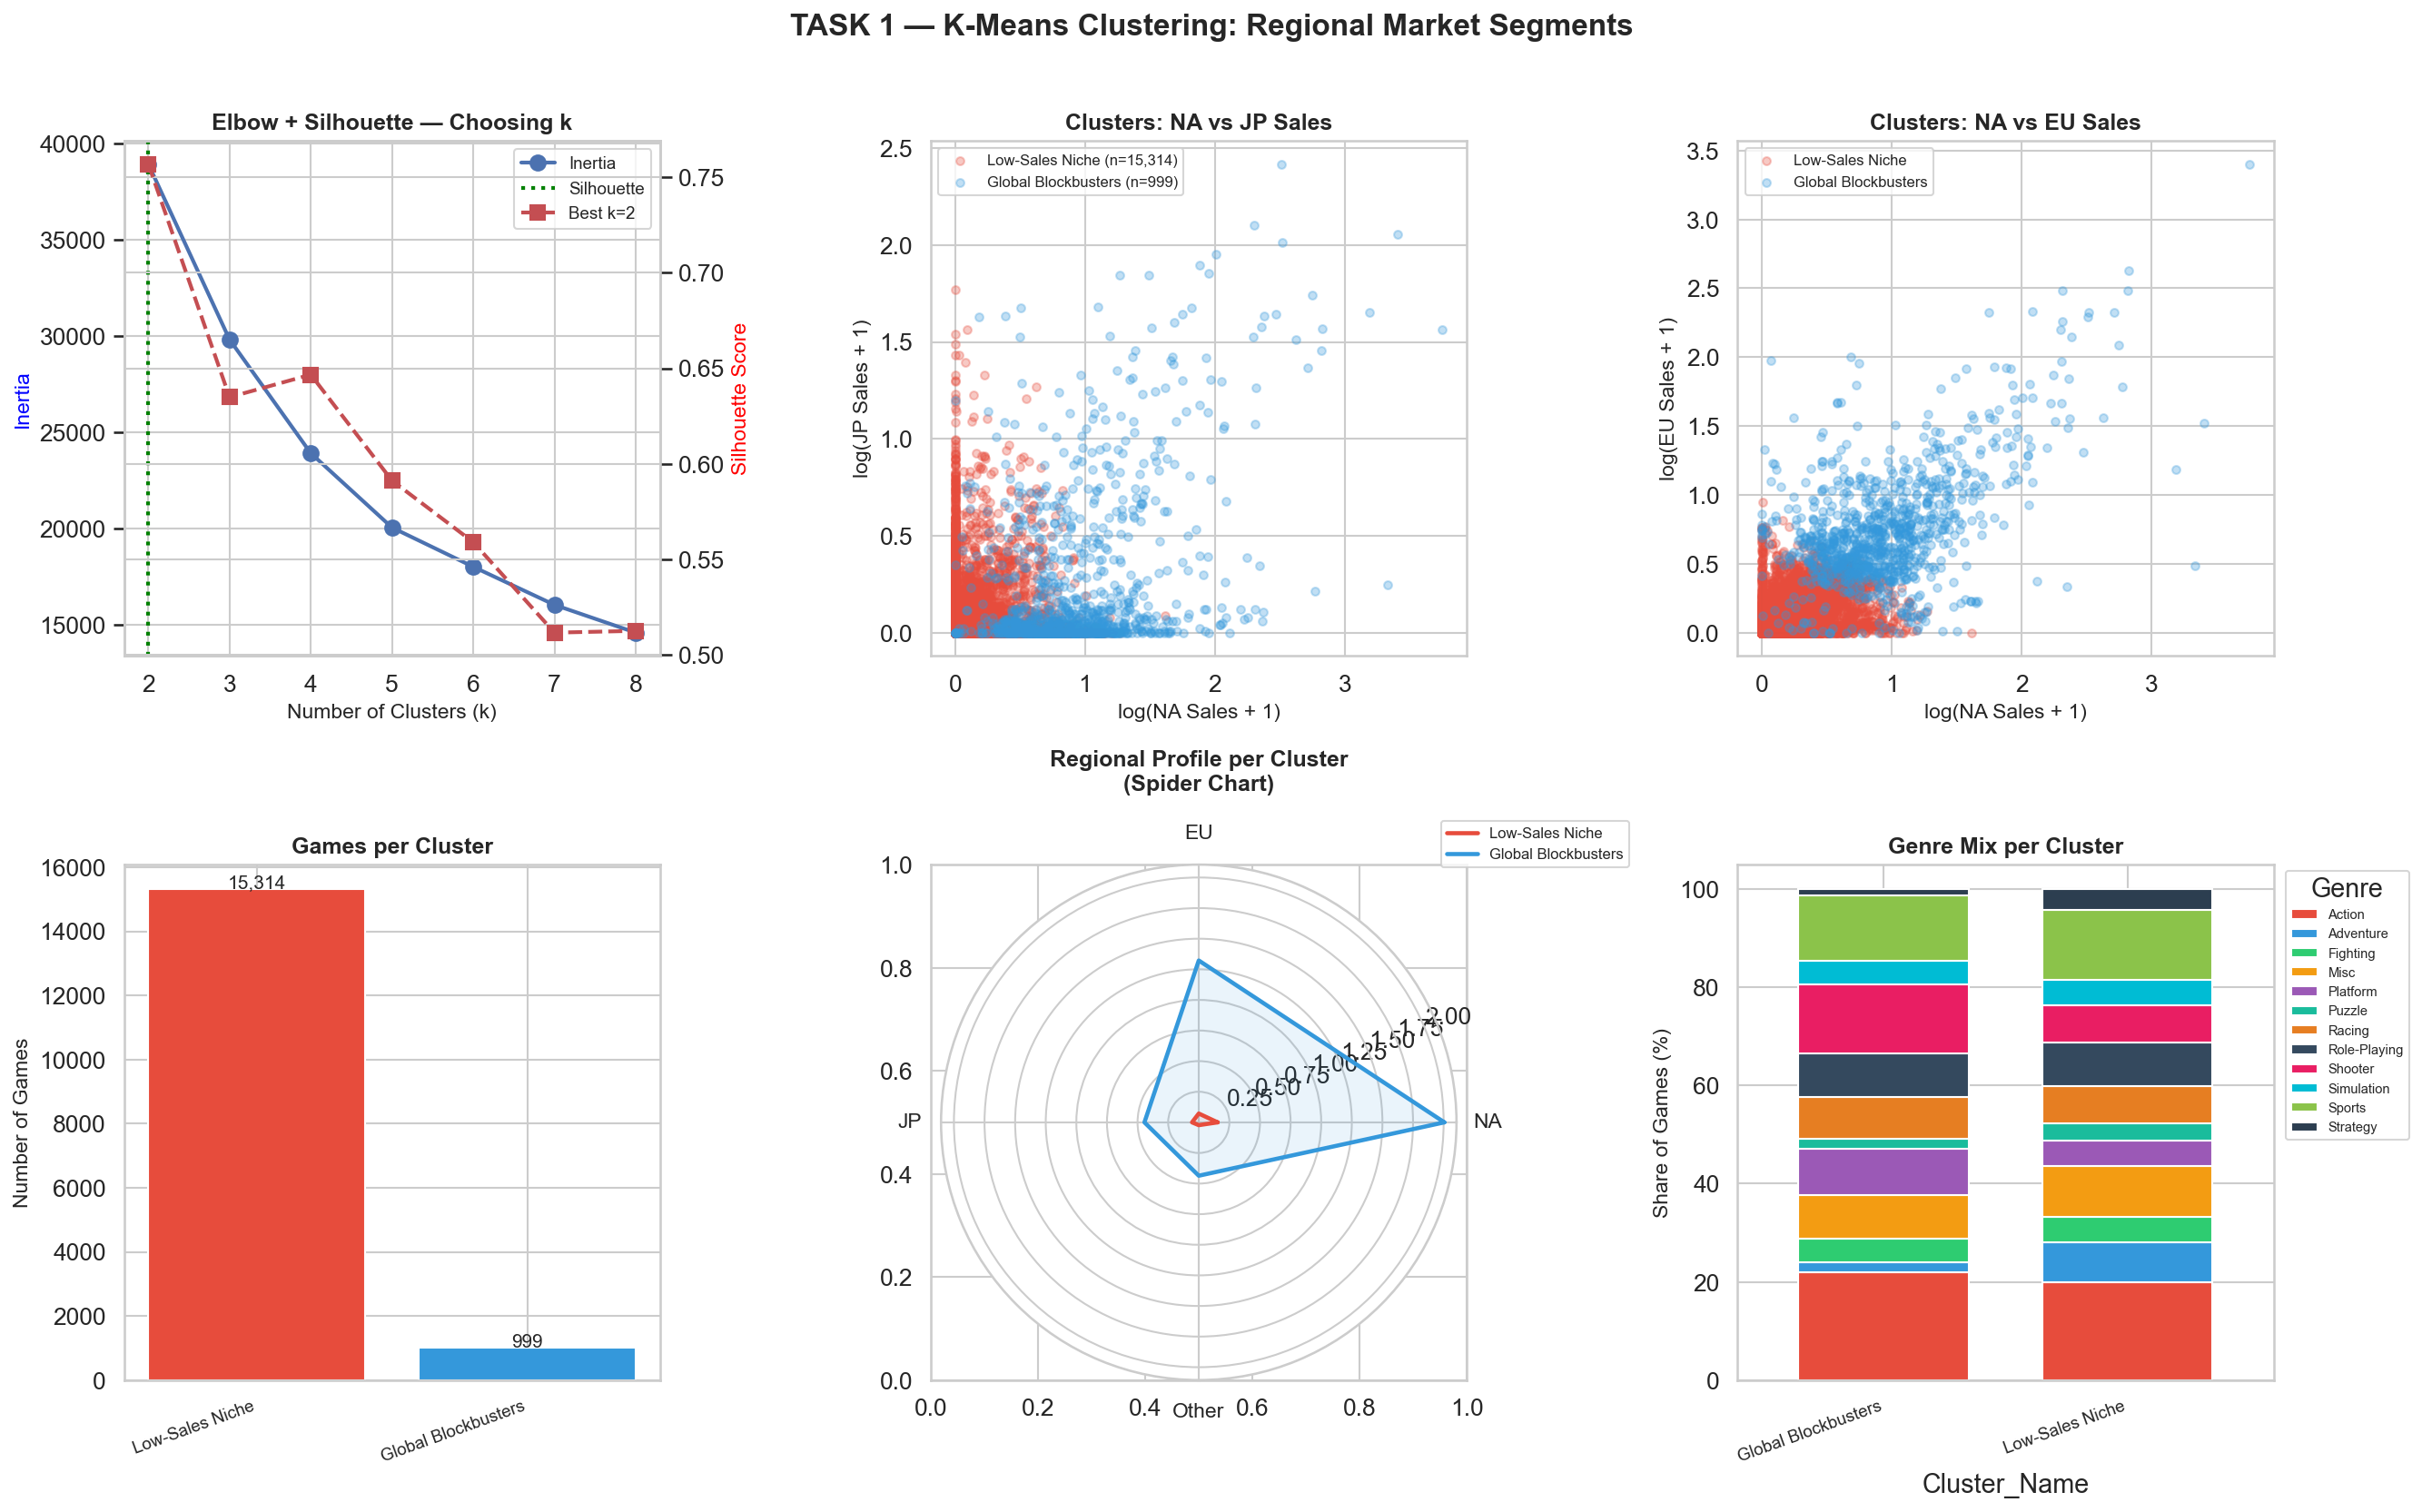

In [210]:
# ══════════════════════════════════════════════════════════════
# TASK 1 — K-MEANS CLUSTERING
# Goal : discover natural market segments from NA/EU/JP sales
# ══════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("TASK 1 — K-MEANS CLUSTERING")
print("═"*60)

# ── 1a. Choose k with Elbow + Silhouette ─────────────────────
from sklearn.metrics import silhouette_score

cluster_features = ['log_NA_Sales','log_EU_Sales',
                    'log_JP_Sales','log_Other_Sales']
X_clus  = df[cluster_features].copy()
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_clus)

inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, lbl))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={sil_scores[-1]:.4f}")

best_k = k_range.start + np.argmax(sil_scores)
print(f"\n  Best k by silhouette score : k = {best_k}")

# ── 1b. Fit final model ───────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df['Cluster'] = km_final.fit_predict(X_sc)

# ── 1c. Profile each cluster and name it ─────────────────────
profile = df.groupby('Cluster').agg(
    Count        = ('Name',       'count'),
    NA_mean      = ('NA_Sales',   'mean'),
    EU_mean      = ('EU_Sales',   'mean'),
    JP_mean      = ('JP_Sales',   'mean'),
    Other_mean   = ('Other_Sales','mean'),
    Global_mean  = ('Global_Sales','mean'),
    Global_med   = ('Global_Sales','median'),
    Top_Genre    = ('Genre', lambda x: x.mode()[0])
).round(3)

print("\n  Cluster Profiles:")
print(profile.to_string())

# auto-name clusters
def name_cluster(row):
    if row['Global_mean'] > profile['Global_mean'].quantile(0.75):
        return 'Global Blockbusters'
    elif row['JP_mean'] == profile['JP_mean'].max():
        return 'Japan-Dominant'
    elif row['NA_mean'] == profile['NA_mean'].max():
        return 'Western Hits'
    elif row['Global_mean'] < profile['Global_mean'].quantile(0.25):
        return 'Low-Sales Niche'
    else:
        return 'Balanced Mid-Tier'

profile['Cluster_Name'] = profile.apply(name_cluster, axis=1)
cluster_name_map = profile['Cluster_Name'].to_dict()
df['Cluster_Name'] = df['Cluster'].map(cluster_name_map)
print("\n  Cluster names assigned:")
for cid, name in cluster_name_map.items():
    n = profile.loc[cid, 'Count']
    g = profile.loc[cid, 'Global_mean']
    print(f"    Cluster {cid} → '{name}'  ({n:,} games, avg={g:.3f}M)")

# ── 1d. Plots ─────────────────────────────────────────────────
cpal = dict(zip(profile.index, PALETTE))
name_colors = {v: PALETTE[k] for k, v in cluster_name_map.items()}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1 — Elbow + Silhouette
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8, label='Inertia')
ax2.plot(list(k_range), sil_scores, 'rs--', linewidth=2, markersize=8, label='Silhouette')
ax.axvline(best_k, color='green', linestyle=':', linewidth=2,
           label=f'Best k={best_k}')
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11, color='blue')
ax2.set_ylabel('Silhouette Score', fontsize=11, color='red')
ax.set_title('Elbow + Silhouette — Choosing k', fontsize=12, fontweight='bold')
lines1, _ = ax.get_legend_handles_labels()
lines2, _ = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, ['Inertia','Silhouette',f'Best k={best_k}'], fontsize=9)

# Plot 2 — Scatter NA vs JP (log) coloured by cluster
ax = axes[0, 1]
for cid, name in cluster_name_map.items():
    sub = df[df['Cluster'] == cid]
    ax.scatter(sub['log_NA_Sales'], sub['log_JP_Sales'],
               color=PALETTE[cid], alpha=0.3, s=18, label=f'{name} (n={len(sub):,})')
ax.set_xlabel('log(NA Sales + 1)', fontsize=11)
ax.set_ylabel('log(JP Sales + 1)', fontsize=11)
ax.set_title('Clusters: NA vs JP Sales', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

# Plot 3 — Scatter NA vs EU (log)
ax = axes[0, 2]
for cid, name in cluster_name_map.items():
    sub = df[df['Cluster'] == cid]
    ax.scatter(sub['log_NA_Sales'], sub['log_EU_Sales'],
               color=PALETTE[cid], alpha=0.3, s=18, label=name)
ax.set_xlabel('log(NA Sales + 1)', fontsize=11)
ax.set_ylabel('log(EU Sales + 1)', fontsize=11)
ax.set_title('Clusters: NA vs EU Sales', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

# Plot 4 — Cluster sizes bar
ax = axes[1, 0]
names  = [cluster_name_map[i] for i in sorted(profile.index)]
counts = [profile.loc[i,'Count'] for i in sorted(profile.index)]
bars = ax.bar(names, counts, color=PALETTE[:best_k], edgecolor='white')
ax.set_ylabel('Number of Games', fontsize=11)
ax.set_title('Games per Cluster', fontsize=12, fontweight='bold')
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, val+30,
            f'{val:,}', ha='center', fontsize=10)

# Plot 5 — Radar / spider chart of cluster profiles
ax = axes[1, 1]
regions     = ['NA','EU','JP','Other']
reg_cols    = ['NA_mean','EU_mean','JP_mean','Other_mean']
angles      = np.linspace(0, 2*np.pi, len(regions), endpoint=False).tolist()
angles     += angles[:1]
ax = plt.subplot(2, 3, 5, polar=True)
for cid, name in cluster_name_map.items():
    vals = [profile.loc[cid, c] for c in reg_cols]
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[cid], linewidth=2.2, label=name)
    ax.fill(angles, vals, color=PALETTE[cid], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(regions, fontsize=11)
ax.set_title('Regional Profile per Cluster\n(Spider Chart)',
             fontsize=12, fontweight='bold', pad=18)
ax.legend(bbox_to_anchor=(1.35, 1.1), fontsize=8)

# Plot 6 — Genre mix per cluster
ax = axes[1, 2]
genre_cluster = df.groupby(['Cluster_Name','Genre'])['Name']\
    .count().unstack(fill_value=0)
genre_pct = genre_cluster.div(genre_cluster.sum(axis=1), axis=0) * 100
genre_pct.plot(kind='bar', stacked=True, ax=ax,
               color=PALETTE[:12], edgecolor='white', width=0.7)
ax.set_ylabel('Share of Games (%)', fontsize=11)
ax.set_title('Genre Mix per Cluster', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), fontsize=7)

plt.suptitle('TASK 1 — K-Means Clustering: Regional Market Segments',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:



# ══════════════════════════════════════════════════════════════
# TASK 2 — RANDOM FOREST CLASSIFIER (Blockbuster Predictor)
# Goal : predict whether a game will be top 10% in sales
# ══════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("TASK 2 — RANDOM FOREST BLOCKBUSTER PREDICTOR")
print("═"*60)

feats_rf = ['genre_enc','plat_enc','pub_enc','Is_Series','Year']
X_rf = df[feats_rf]
y_rf = df['Blockbuster']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

# ── 2a. Baseline: Decision Tree (interpretable) ───────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42,
                             class_weight='balanced')
dt.fit(X_tr, y_tr)
dt_pred = dt.predict(X_te)
dt_auc  = roc_auc_score(y_te, dt.predict_proba(X_te)[:,1])
print(f"\n  Decision Tree (depth=4): AUC={dt_auc:.4f}")
print(export_text(dt, feature_names=feats_rf, max_depth=3))

# ── 2b. Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_prob = rf.predict_proba(X_te)[:,1]
rf_pred = rf.predict(X_te)
rf_auc  = roc_auc_score(y_te, rf_prob)
rf_f1   = f1_score(y_te, rf_pred)
cv_rf   = cross_val_score(rf, X_rf, y_rf, cv=5,
                           scoring='roc_auc', n_jobs=-1)

print(f"\n  Random Forest:")
print(f"    AUC          : {rf_auc:.4f}")
print(f"    F1 Score     : {rf_f1:.4f}")
print(f"    CV AUC       : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_te, rf_pred,
      target_names=['Not Blockbuster','Blockbuster']))

# feature importance
imp = pd.Series(rf.feature_importances_, index=feats_rf)\
        .sort_values(ascending=False)
print(f"\n  Feature Importances:")
for f, v in imp.items():
    bar = '█' * int(v*50)
    print(f"    {f:<15}: {v:.4f}  {bar}")

# ── 2c. Logistic Regression baseline ─────────────────────────
from sklearn.preprocessing import StandardScaler as SS
sc2 = SS()
lr  = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(sc2.fit_transform(X_tr), y_tr)
lr_prob = lr.predict_proba(sc2.transform(X_te))[:,1]
lr_auc  = roc_auc_score(y_te, lr_prob)
print(f"\n  Logistic Regression baseline: AUC={lr_auc:.4f}")

# ── 2d. Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1 — ROC Curve comparison
ax = axes[0, 0]
for prob, auc, label, color, ls in [
    (rf_prob, rf_auc, 'Random Forest', '#E74C3C', '-'),
    (lr_prob, lr_auc, 'Logistic Reg',  '#3498DB', '--'),
    (dt.predict_proba(X_te)[:,1], dt_auc, 'Decision Tree', '#2ECC71', ':'),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            linestyle=ls, label=f'{label} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5)
ax.fill_between(*roc_curve(y_te, rf_prob)[:2], alpha=0.08, color='#E74C3C')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — All Models', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Plot 2 — Confusion Matrix (RF)
ax = axes[0, 1]
cm = confusion_matrix(y_te, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not BB','Blockbuster'],
            yticklabels=['Not BB','Blockbuster'],
            linewidths=0.5, cbar=False)
ax.set_title('Confusion Matrix — Random Forest',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)

tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.18,
        f'TP={tp}  FP={fp}  FN={fn}  TN={tn}  '
        f'Precision={tp/(tp+fp):.2f}  Recall={tp/(tp+fn):.2f}',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Plot 3 — Feature Importance
ax = axes[0, 2]
imp_sorted = imp.sort_values()
colors_imp = ['#E74C3C' if v == imp.max() else '#3498DB'
               for v in imp_sorted.values]
bars = ax.barh(imp_sorted.index, imp_sorted.values,
               color=colors_imp, edgecolor='white', height=0.6)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance\n(★ = most important)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, imp_sorted.values):
    ax.text(val + 0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlim(0, imp_sorted.max()*1.25)

# Plot 4 — Predicted probability distribution
ax = axes[1, 0]
ax.hist(rf_prob[y_te==0], bins=50, alpha=0.6, color='#3498DB',
        label='Not Blockbuster', density=True)
ax.hist(rf_prob[y_te==1], bins=50, alpha=0.6, color='#E74C3C',
        label='Blockbuster', density=True)
ax.axvline(0.5, color='black', linewidth=1.5, linestyle='--', label='Threshold=0.5')
ax.set_xlabel('Predicted Probability of Blockbuster', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Predicted Probability Distribution',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Plot 5 — CV scores per fold
ax = axes[1, 1]
bars = ax.bar(range(1, 6), cv_rf, color=PALETTE[:5], edgecolor='white', width=0.6)
ax.axhline(cv_rf.mean(), color='#E74C3C', linewidth=2, linestyle='--',
           label=f'Mean AUC = {cv_rf.mean():.3f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_title('5-Fold Cross-Validation AUC\n(checks for overfitting)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, min(1.0, cv_rf.max()*1.2))
for bar, val in zip(bars, cv_rf):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005,
            f'{val:.3f}', ha='center', fontsize=10)

# Plot 6 — Blockbuster rate per genre
ax = axes[1, 2]
bb_rate = df.groupby('Genre')['Blockbuster'].mean().sort_values(ascending=False)
bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(bb_rate))]
bars = ax.bar(bb_rate.index, bb_rate.values * 100,
              color=bar_colors, edgecolor='white')
ax.axhline(10, color='red', linewidth=1.5, linestyle='--',
           label='10% baseline')
ax.set_ylabel('% of Games that are Blockbusters', fontsize=11)
ax.set_title('Blockbuster Rate by Genre', fontsize=12, fontweight='bold')
ax.set_xticklabels(bb_rate.index, rotation=38, ha='right', fontsize=9)
ax.legend(fontsize=10)
for bar, val in zip(bars, bb_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, val*100+0.3,
            f'{val*100:.1f}%', ha='center', fontsize=8)

plt.suptitle('TASK 2 — Random Forest: Blockbuster Predictor',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ML_task2_randomforest.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Saved: ML_task2_randomforest.png")


In [ ]:


# ══════════════════════════════════════════════════════════════
# TASK 3 — GENRE PREDICTOR
# Goal : given a game's regional sales pattern, predict genre
# Why interesting: different genres dominate different regions
# ══════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("TASK 3 — GENRE PREDICTOR")
print("═"*60)

# Features: regional sales ratios + total + year
df['NA_share']  = df['NA_Sales']    / (df['Global_Sales'] + 0.001)
df['EU_share']  = df['EU_Sales']    / (df['Global_Sales'] + 0.001)
df['JP_share']  = df['JP_Sales']    / (df['Global_Sales'] + 0.001)
df['Oth_share'] = df['Other_Sales'] / (df['Global_Sales'] + 0.001)

feats_gp = ['log_Global_Sales','NA_share','EU_share',
            'JP_share','Oth_share','Year','plat_enc']
X_gp = df[feats_gp]
y_gp = df['genre_enc']    # 0–11 (12 genres)

X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_gp, y_gp, test_size=0.2, random_state=42, stratify=y_gp)

# Random Forest for multi-class genre prediction
rf_gp = RandomForestClassifier(
    n_estimators=300, max_depth=12,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)
rf_gp.fit(X_tr_g, y_tr_g)
gp_pred  = rf_gp.predict(X_te_g)
gp_acc   = accuracy_score(y_te_g, gp_pred)
gp_f1    = f1_score(y_te_g, gp_pred, average='macro')
cv_gp    = cross_val_score(rf_gp, X_gp, y_gp, cv=5,
                            scoring='accuracy', n_jobs=-1)

genre_names = le_genre.classes_
print(f"\n  Accuracy  : {gp_acc:.4f}")
print(f"  Macro F1  : {gp_f1:.4f}")
print(f"  CV Acc    : {cv_gp.mean():.4f} ± {cv_gp.std():.4f}")

# Random baseline
baseline = df['Genre'].value_counts(normalize=True).max()
print(f"  Baseline (always predict '{df['Genre'].mode()[0]}'): {baseline:.4f}")
print(f"  RF improvement over baseline: +{(gp_acc-baseline)*100:.1f}pp")

print(f"\n  Classification Report (Genre Predictor):")
print(classification_report(y_te_g, gp_pred, target_names=genre_names))

# Feature importances
imp_gp = pd.Series(rf_gp.feature_importances_, index=feats_gp)\
           .sort_values(ascending=False)

# ── 3d. Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Confusion matrix (genre x genre)
ax = axes[0, 0]
cm_gp = confusion_matrix(y_te_g, gp_pred)
cm_norm = cm_gp.astype(float) / cm_gp.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=genre_names, yticklabels=genre_names,
            ax=ax, linewidths=0.3, cbar_kws={'label':'Recall Rate'})
ax.set_title('Genre Predictor — Confusion Matrix\n(row-normalised recall)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(genre_names, rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(genre_names, rotation=0, fontsize=8)
ax.set_ylabel('Actual Genre', fontsize=11)
ax.set_xlabel('Predicted Genre', fontsize=11)

# Plot 2 — Feature Importance
ax = axes[0, 1]
imp_gp_sorted = imp_gp.sort_values()
bar_cols = ['#E74C3C' if f in ['JP_share','NA_share'] else '#3498DB'
             for f in imp_gp_sorted.index]
bars = ax.barh(imp_gp_sorted.index, imp_gp_sorted.values,
               color=bar_cols, edgecolor='white', height=0.6)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance — Genre Predictor\n'
             '(Red = regional shares)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, imp_gp_sorted.values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlim(0, imp_gp_sorted.max()*1.25)

# Plot 3 — Per-genre accuracy (recall on diagonal)
ax = axes[1, 0]
per_genre_recall = cm_norm.diagonal()
sorted_idx = np.argsort(per_genre_recall)[::-1]
bar_cols2 = ['#2ECC71' if v >= gp_acc else '#E74C3C'
              for v in per_genre_recall[sorted_idx]]
bars = ax.bar(genre_names[sorted_idx], per_genre_recall[sorted_idx]*100,
              color=bar_cols2, edgecolor='white')
ax.axhline(gp_acc*100, color='#3498DB', linewidth=2, linestyle='--',
           label=f'Overall Acc={gp_acc*100:.1f}%')
ax.set_ylabel('Recall (%)', fontsize=11)
ax.set_title('Per-Genre Recall\n(Green = above avg, Red = below)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(genre_names[sorted_idx], rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10)
for bar, val in zip(bars, per_genre_recall[sorted_idx]*100):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5,
            f'{val:.0f}%', ha='center', fontsize=8)

# Plot 4 — Regional share fingerprint per genre
ax = axes[1, 1]
reg_profile = df.groupby('Genre')[['NA_share','EU_share',
                                    'JP_share','Oth_share']].mean()
reg_profile.columns = ['NA','EU','JP','Other']
reg_profile.plot(kind='bar', ax=ax, color=['#E74C3C','#3498DB','#2ECC71','#F39C12'],
                 edgecolor='white', width=0.75)
ax.set_ylabel('Average Regional Share', fontsize=11)
ax.set_title('Regional Sales Profile per Genre\n'
             '(this is what the model learns from)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=38, ha='right', fontsize=9)
ax.legend(title='Region', fontsize=10)
ax.set_ylim(0, 0.85)

plt.suptitle('TASK 3 — Genre Predictor: Classify Genre from Sales Pattern',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ML_task3_genre_predictor.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Saved: ML_task3_genre_predictor.png")


# ══════════════════════════════════════════════════════════════
# TASK 4 — ANOMALY DETECTION (Isolation Forest)
# Goal : find games that are statistically unusual —
#         massive hits nobody predicted, or weird sales patterns
# ══════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("TASK 4 — ANOMALY DETECTION (Isolation Forest)")
print("═"*60)

# Features: all 4 regional sales (log scale)
feats_an = ['log_NA_Sales','log_EU_Sales',
            'log_JP_Sales','log_Other_Sales','log_Global_Sales']
X_an  = df[feats_an]
sc_an = StandardScaler()
X_an_sc = sc_an.fit_transform(X_an)

# contamination = expected % of anomalies (1% = top 1% outliers)
iso = IsolationForest(n_estimators=300, contamination=0.02,
                       random_state=42, n_jobs=-1)
df['Anomaly_Score']  = iso.fit_predict(X_an_sc)          # -1 = anomaly
df['Anomaly_Raw']    = iso.decision_function(X_an_sc)    # lower = more anomalous
df['Is_Anomaly']     = df['Anomaly_Score'] == -1

n_anomalies = df['Is_Anomaly'].sum()
print(f"\n  Total anomalies detected : {n_anomalies:,} ({n_anomalies/len(df)*100:.1f}%)")

# Show the most extreme anomalies
anomalies = df[df['Is_Anomaly']].sort_values('Anomaly_Raw').head(30)
print(f"\n  Top 20 Most Anomalous Games:")
cols_show = ['Name','Genre','Publisher','Global_Sales',
             'NA_Sales','EU_Sales','JP_Sales','Anomaly_Raw']
print(anomalies[cols_show].head(20).to_string(index=False))

# Categorise anomalies
df['Anomaly_Type'] = 'Normal'
df.loc[df['Is_Anomaly'], 'Anomaly_Type'] = 'Other Anomaly'
df.loc[df['Is_Anomaly'] & (df['JP_Sales'] > df['NA_Sales']*2), 'Anomaly_Type'] = 'JP Outlier'
df.loc[df['Is_Anomaly'] & (df['NA_Sales'] > df['JP_Sales']*10), 'Anomaly_Type'] = 'NA Outlier'
df.loc[df['Is_Anomaly'] & (df['Global_Sales'] > thresh), 'Anomaly_Type'] = 'Mega Hit'

print(f"\n  Anomaly type breakdown:")
print(df[df['Is_Anomaly']]['Anomaly_Type'].value_counts())

# ── 4d. Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1 — Anomaly score distribution
ax = axes[0, 0]
ax.hist(df['Anomaly_Raw'], bins=60, color='#3498DB',
        edgecolor='white', alpha=0.85)
thresh_score = df[df['Is_Anomaly']]['Anomaly_Raw'].max()
ax.axvline(thresh_score, color='#E74C3C', linewidth=2,
           linestyle='--', label=f'Anomaly threshold')
ax.set_xlabel('Anomaly Score (lower = more anomalous)', fontsize=11)
ax.set_ylabel('Number of Games', fontsize=11)
ax.set_title('Anomaly Score Distribution\n'
             '(left tail = outliers)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Plot 2 — Scatter NA vs JP, anomalies highlighted
ax = axes[0, 1]
normal   = df[~df['Is_Anomaly']]
anoms    = df[df['Is_Anomaly']]
ax.scatter(normal['log_NA_Sales'], normal['log_JP_Sales'],
           color='#BDC3C7', alpha=0.2, s=12, label='Normal')
ax.scatter(anoms['log_NA_Sales'], anoms['log_JP_Sales'],
           color='#E74C3C', alpha=0.75, s=40, zorder=5, label='Anomaly')

# label top outliers
for _, row in anoms.nsmallest(8, 'Anomaly_Raw').iterrows():
    ax.annotate(row['Name'][:20],
                xy=(row['log_NA_Sales'], row['log_JP_Sales']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=7, color='#C0392B',
                arrowprops=dict(arrowstyle='-', color='grey', lw=0.8))
ax.set_xlabel('log(NA Sales + 1)', fontsize=11)
ax.set_ylabel('log(JP Sales + 1)', fontsize=11)
ax.set_title('Anomalies: NA vs JP Sales\n(red = anomalous)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Plot 3 — Global sales: normal vs anomaly
ax = axes[0, 2]
plot_df = pd.DataFrame({
    'Sales': pd.concat([
        normal['Global_Sales'].clip(upper=20),
        anoms['Global_Sales'].clip(upper=20)
    ]),
    'Type': ['Normal']*len(normal) + ['Anomaly']*len(anoms)
})
sns.violinplot(data=plot_df, x='Type', y='Sales',
               palette=['#3498DB','#E74C3C'], ax=ax, inner='box',
               hue='Type', legend=False)
ax.set_ylabel('Global Sales (M, clipped 20M)', fontsize=11)
ax.set_title('Sales Distribution\nNormal vs Anomaly',
             fontsize=12, fontweight='bold')
ax.text(0.5, 0.97,
        f'Anomaly median={anoms["Global_Sales"].median():.2f}M\n'
        f'Normal median={normal["Global_Sales"].median():.2f}M',
        transform=ax.transAxes, ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Plot 4 — Top anomalies bar chart
ax = axes[1, 0]
top_anoms = anoms.groupby('Name')['Global_Sales'].sum()\
                 .sort_values(ascending=False).head(15)
colors_an = ['#E74C3C' if v > thresh else '#F39C12'
              for v in top_anoms.values]
bars = ax.barh(top_anoms.index[::-1], top_anoms.values[::-1],
               color=colors_an[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Global Sales (M)', fontsize=11)
ax.set_title('Top 15 Detected Anomaly Games\n'
             '(Red = mega hit, Orange = unusual pattern)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, top_anoms.values[::-1]):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=8.5)

# Plot 5 — Anomaly type breakdown
ax = axes[1, 1]
at_counts = df[df['Is_Anomaly']]['Anomaly_Type'].value_counts()
wedges, texts, autotexts = ax.pie(
    at_counts.values, labels=at_counts.index,
    colors=['#E74C3C','#F39C12','#3498DB','#9B59B6'],
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize':10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Anomaly Type Breakdown', fontsize=12, fontweight='bold')

# Plot 6 — Anomalies per genre
ax = axes[1, 2]
anom_rate = df.groupby('Genre')['Is_Anomaly'].mean() * 100
anom_sorted = anom_rate.sort_values(ascending=False)
bar_cols3 = ['#E74C3C' if v > anom_rate.mean() else '#3498DB'
              for v in anom_sorted.values]
bars = ax.bar(anom_sorted.index, anom_sorted.values,
              color=bar_cols3, edgecolor='white')
ax.axhline(anom_rate.mean(), color='black', linewidth=1.5, linestyle='--',
           label=f'Avg={anom_rate.mean():.1f}%')
ax.set_ylabel('% Anomalies', fontsize=11)
ax.set_title('Anomaly Rate per Genre\n(Red = above average)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(anom_sorted.index, rotation=38, ha='right', fontsize=9)
ax.legend(fontsize=10)

plt.suptitle('TASK 4 — Anomaly Detection: Finding Unusual Games',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ML_task4_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Saved: ML_task4_anomaly.png")


# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY — all 4 tasks
# ══════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("FINAL SUMMARY — ALL 4 ML TASKS")
print("═"*60)
print(f"""
┌──────────────────────┬─────────────────────────────────────────────┐
│ TASK                 │ KEY RESULT                                  │
├──────────────────────┼─────────────────────────────────────────────┤
│ K-Means Clustering   │ Best k={best_k} clusters (silhouette)             │
│                      │ Clusters: {', '.join(cluster_name_map.values())} │
├──────────────────────┼─────────────────────────────────────────────┤
│ RF Blockbuster       │ AUC={rf_auc:.3f}  F1={rf_f1:.3f}                      │
│                      │ CV AUC={cv_rf.mean():.3f}±{cv_rf.std():.3f}                 │
│                      │ Top feature: {imp.idxmax()} ({imp.max():.3f})          │
├──────────────────────┼─────────────────────────────────────────────┤
│ Genre Predictor      │ Accuracy={gp_acc:.3f}  Macro-F1={gp_f1:.3f}            │
│                      │ Best genre: best recall on diagonal        │
│                      │ vs baseline ({baseline:.3f}) +{(gp_acc-baseline)*100:.1f}pp  │
├──────────────────────┼─────────────────────────────────────────────┤
│ Anomaly Detection    │ {n_anomalies:,} anomalies detected ({n_anomalies/len(df)*100:.1f}% of data)   │
│                      │ Includes mega-hits + unusual patterns      │
└──────────────────────┴─────────────────────────────────────────────┘
""")
print("All 4 plots saved! ✓")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/uploads/vgsales.csv'